# Notebook 05 . Analyse de cadrage VSS x Immigration

## Objectif

Ce notebook est le coeur de l'analyse. On s'interesse aux phrases des debats parlementaires qui mentionnent
**en meme temps** les violences sexistes et sexuelles (VSS) et l'immigration ou les minorites religieuses.
Pour chacune de ces phrases, on cherche a determiner le **cadrage** utilise par l'orateur :

| Cadrage | Ce que l'orateur fait |
|---|---|
| **ACCUSATEUR** | Il presente l'immigration ou l'islam comme la *cause* des VSS |
| **VICTIME** | Il presente les immigres ou les minorites comme *victimes* de violences |
| **NEUTRE** | Il fait une mention administrative, factuelle, ou il denonce l'amalgame |

On applique **quatre methodes complementaires**, de la plus simple a la plus sophistiquee,
pour verifier que les resultats convergent (approche de **triangulation methodologique**).

## Les 4 methodes

1. **V1 . Lexique de cadrage** : score bidirectionnel (accusateur ET victime) par comptage de mots
2. **V2 . Patterns syntaxiques** : expressions regulieres orientees role (sujet-verbe-objet)
3. **V3 . Zero-shot NLI (CamemBERT)** : classification par inference en langage naturel
4. **V4 . Classification LLM** : Mistral (via API ENSAE) avec Chain-of-Thought structure

La triangulation de methodes symboliques (V1-V2) et neuronales (V3-V4) est une pratique
recommandee par Grimmer, Roberts & Stewart (2022, *Text as Data*) pour eviter de dependre
d'une seule famille de modeles.

## Donnees

On charge `df_vss_propre.pkl` produit par le notebook 02.

## 0. Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re, os, time
from collections import defaultdict, Counter
from tqdm import tqdm
from dotenv import load_dotenv

# ==============================================================
# STYLE GRAPHIQUE
# ==============================================================

import matplotlib.pyplot as plt
import matplotlib as mpl

PALETTE_PASTEL = ["#A8D8EA", "#AA96DA", "#FCBAD3", "#FFFFD2", "#B5EAD7",
                  "#C7CEEA", "#FFB7B2", "#E2F0CB", "#FFDAC1", "#B5B8FF"]

COULEURS_BLOCS = {
    "Extrême Droite":        "#E88D9A",
    "Droite Traditionnelle": "#7BAFD4",
    "Centre":                "#F2CC8F",
    "Gauche Modérée":        "#81B29A",
    "Gauche Radicale":       "#D4A5A5",
}

ORDRE_BLOCS = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'font.weight': 'light',
    'axes.titlesize': 13,
    'axes.titleweight': 'normal',
    'axes.labelsize': 11,
    'axes.labelweight': 'light',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#CCCCCC',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': '#DDDDDD',
    'legend.frameon': False,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'text.color': '#222222',
})

print("Style graphique chargé.")


chemin_propre = "/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl"

if not os.path.exists(chemin_propre):
    print(f"Fichier introuvable a la racine, on cherche dans dataframes/...")
    chemin_propre = "/home/onyxia/work/projet_eco_socio/dataframes/df_vss_propre.pkl"

df_vss = pd.read_pickle(chemin_propre)
df_vss['date'] = pd.to_datetime(df_vss['date'])
df_vss = df_vss.dropna(subset=['bloc']).copy()

print(f"{len(df_vss)} prises de parole VSS chargées.")
for bloc in ORDRE_BLOCS:
    n = len(df_vss[df_vss['bloc'] == bloc])
    print(f"  {bloc:30s} : {n:5d}")

Style graphique chargé.
4052 prises de parole VSS chargées.
  Extrême Droite                 :   524
  Droite Traditionnelle          :   580
  Centre                         :  1316
  Gauche Modérée                 :   646
  Gauche Radicale                :   986


### Vocabulaire de recherche

On définit les deux listes de racines de mots qui servent a détecter les cooccurrences :
les mots du champ **VSS** et ceux du champ **identitaire / migratoire**.

In [2]:
GROUPES_CIBLES = [
    "immigr", "clandestin", "étranger", "migrant", "réfugié", "exilé", "demandeur d'asile",
    "sans-papier", "sans papier", "oqtf", "expulsion", "frontière", "reconduite", "éloignement",
    "islam", "musulman", "charia", "voile", "abaya", "burqa", "qamis",
    "confession", "séparatisme", "communautarisme", "assimilation", "intégration",
    "maghrébin", "africain", "arabe", "origine étrangère", "civilisation",
    "ensauvagement", "décivilisation", "grand remplacement", "racaille", "délinquan"
]

MOTS_VSS = [
    "viol", "agress", "féminicide", "mutilation", "prostitu", "proxénét", "tournante",
    "harcel", "harcèl", "cyberharcèl", "cyber-harcèl",
    "sexuel", "sexis", "conjugal", "inceste", "pédocrimin", "pédophil",
    "patriarca", "misogyn", "machis", "emprise", "soumission", "consentement",
    "stéréotype", "domination masculine", "culture du viol", "me too", "metoo"
]

print(f"{len(GROUPES_CIBLES)} racines identitaires, {len(MOTS_VSS)} racines VSS.")

36 racines identitaires, 28 racines VSS.


## 1. Extraction des phrases de cooccurrence

Avant d'appliquer les 4 méthodes, il faut isoler les phrases qui parlent des deux sujets a la fois.
On utilise deux modes complémentaires :

- **Mode direct** : les deux vocabulaires apparaissent dans la même phrase
- **Mode fenêtre** : un mot VSS dans une phrase, un mot identitaire dans une phrase voisine (plus ou moins 2 phrases)

Le mode fenêtre est important car un député peut dire "ces agressions sexuelles sont inadmissibles"
dans une phrase, puis "et ce sont des étrangers sous OQTF" dans la suivante.

In [3]:
def extraire_contextes(df_vss, fenetre_phrases=2):
    pat_groupe = re.compile(
        r"(?i)\b(" + "|".join([re.escape(m) for m in GROUPES_CIBLES]) + r")\w*\b"
    )
    pat_vss = re.compile(
        r"(?i)\b(" + "|".join([re.escape(m) for m in MOTS_VSS]) + r")\w*\b"
    )

    resultats = []
    for _, row in tqdm(df_vss.iterrows(), total=len(df_vss), desc="Extraction"):
        texte = str(row.get("texte", ""))
        bloc = row.get("bloc")
        if not texte or pd.isna(bloc):
            continue
        phrases = [p.strip() for p in re.split(r"[.!?;]+", texte) if len(p.strip().split()) >= 5]
        n = len(phrases)
        for i, phrase in enumerate(phrases):
            a_vss = bool(pat_vss.search(phrase))
            a_groupe = bool(pat_groupe.search(phrase))
            if a_vss and a_groupe:
                resultats.append({
                    "contexte": phrase, "bloc": bloc,
                    "nom_parti": row.get("nom_parti"), "date": row.get("date"),
                    "mode": "directe"
                })
            elif a_vss:
                debut = max(0, i - fenetre_phrases)
                fin = min(n, i + fenetre_phrases + 1)
                voisines = phrases[debut:i] + phrases[i+1:fin]
                if any(pat_groupe.search(v) for v in voisines):
                    resultats.append({
                        "contexte": " ".join(phrases[debut:fin]), "bloc": bloc,
                        "nom_parti": row.get("nom_parti"), "date": row.get("date"),
                        "mode": "fenetre"
                    })

    df = pd.DataFrame(resultats).drop_duplicates(subset="contexte")
    print(f"\n{len(df)} contextes extraits ({df['mode'].value_counts().to_dict()})")
    return df

df_contextes = extraire_contextes(df_vss)

Extraction:   7%|▋         | 291/4052 [00:00<00:02, 1484.96it/s]

Extraction: 100%|██████████| 4052/4052 [00:02<00:00, 1701.05it/s]


562 contextes extraits ({'fenetre': 311, 'directe': 251})


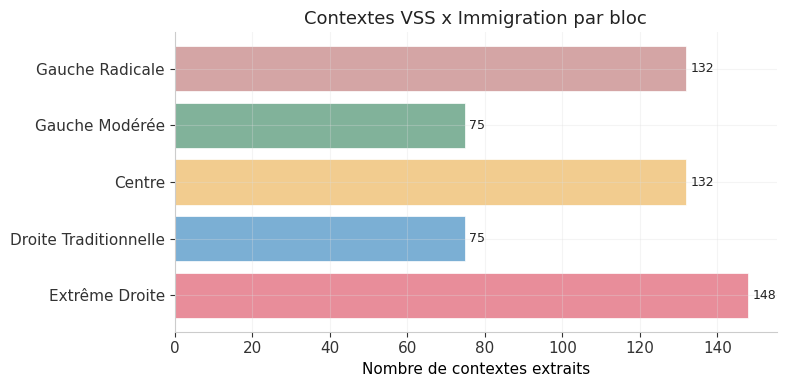

In [4]:
# Répartition des contextes par bloc
fig, ax = plt.subplots(figsize=(8, 4))
counts = df_contextes['bloc'].value_counts().reindex(ORDRE_BLOCS).fillna(0)
colors = [COULEURS_BLOCS[b] for b in counts.index]
ax.barh(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.5)
for i, v in enumerate(counts.values):
    ax.text(v + 1, i, f"{int(v)}", va='center', fontsize=9)
ax.set_xlabel("Nombre de contextes extraits")
ax.set_title("Contextes VSS x Immigration par bloc")
plt.tight_layout()
plt.show()

### Fonctions de visualisation communes

In [5]:
def tracer_barres_empilees(df, col_cadrage, titre=""):
    blocs_presents = [b for b in ORDRE_BLOCS if b in df["bloc"].unique()]
    counts = (df.groupby(["bloc", col_cadrage]).size()
              .unstack(fill_value=0).reindex(blocs_presents))
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    for col in ["ACCUSATEUR", "NEUTRE", "VICTIME", "AMBIGU"]:
        if col not in pct.columns:
            pct[col] = 0
    coul = {"ACCUSATEUR": "#E88D9A", "AMBIGU": "#F2CC8F", "NEUTRE": "#C7CEEA", "VICTIME": "#7BAFD4"}
    fig, ax = plt.subplots(figsize=(10, 6))
    bottom = np.zeros(len(pct))
    cats = [c for c in ["ACCUSATEUR", "AMBIGU", "NEUTRE", "VICTIME"] if pct[c].sum() > 0]
    for cat in cats:
        vals = pct[cat].values
        ax.bar(pct.index, vals, bottom=bottom, color=coul.get(cat, "#DDD"),
               label=cat, edgecolor="white", lw=0.8)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 4:
                ax.text(i, b + v/2, f"{v:.0f}%", ha="center", va="center", fontsize=9, color="#333")
        bottom += vals
    ax.set_ylim(0, 100)
    ax.set_ylabel("Part des contextes (%)")
    ax.set_title(titre)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()


def tracer_score_net(df, col_score, titre=""):
    stats = (df.groupby("bloc")[col_score]
             .agg(["mean", "sem", "count"])
             .rename(columns={"mean": "m", "sem": "e", "count": "n"})
             .reset_index())
    stats = stats[stats["bloc"].isin(ORDRE_BLOCS)]
    stats["bloc"] = pd.Categorical(stats["bloc"], categories=ORDRE_BLOCS, ordered=True)
    stats = stats.sort_values("bloc")
    couleurs = [COULEURS_BLOCS.get(b, "#DDD") for b in stats["bloc"]]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(stats["bloc"], stats["m"], xerr=stats["e"], color=couleurs,
            edgecolor="white", capsize=3, linewidth=0.8,
            error_kw={"elinewidth": 1, "ecolor": "#999", "capthick": 1})
    ax.axvline(0, color="#999", lw=1)
    for i, row in enumerate(stats.itertuples()):
        x = row.m
        ax.text(x + (0.01 if x >= 0 else -0.01), i,
                f"  {x:.3f}  (n={int(row.n)})", va="center",
                ha="left" if x >= 0 else "right", fontsize=9)
    ax.set_title(titre)
    ax.set_xlabel("protecteur / victime  .  accusateur")
    plt.tight_layout()
    plt.show()


def tracer_evolution(df, col_score, titre=""):
    d = df.copy()
    d["date"] = pd.to_datetime(d["date"], errors="coerce")
    d["annee"] = d["date"].dt.year
    d = d.dropna(subset=["annee"])
    d = d[d["annee"] >= 2018]  # exclure 2017 (donnees incompletes)
    evol = d.groupby(["annee", "bloc"])[col_score].mean().reset_index()
    evol = evol[evol["bloc"].isin(ORDRE_BLOCS)]
    fig, ax = plt.subplots(figsize=(11, 6))
    for bloc in ORDRE_BLOCS:
        sub = evol[evol["bloc"] == bloc].sort_values("annee")
        if sub.empty: continue
        ax.plot(sub["annee"], sub[col_score], marker="o", label=bloc,
                color=COULEURS_BLOCS.get(bloc, "#DDD"), lw=2, markersize=6)
    ax.axhline(0, color="#999", lw=1, ls="--")
    ax.set_title(titre)
    ax.set_xlabel("Annee")
    annees = sorted(evol["annee"].dropna().unique())
    if annees:
        ax.set_xticks([int(a) for a in annees])
    ax.set_ylabel("Score net moyen")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def afficher_exemples(df, col_cadrage, n=2):
    print("\n" + "=" * 80)
    print("VALIDATION QUALITATIVE")
    print("=" * 80)
    for bloc in ORDRE_BLOCS:
        sub = df[df["bloc"] == bloc]
        if sub.empty: continue
        print(f"\n{'.'*65}")
        print(f"  {bloc.upper()} . {len(sub)} contextes")
        print(f"  {sub[col_cadrage].value_counts().to_dict()}")
        for cadrage in ["ACCUSATEUR", "VICTIME"]:
            sous = sub[sub[col_cadrage] == cadrage].head(n)
            if sous.empty: continue
            print(f"\n  [{cadrage}]")
            for _, row in sous.iterrows():
                txt = str(row["contexte"])[:250]
                print(f'    [{row.get("nom_parti", "?")}] "{txt}..."')
                if "justification" in row and pd.notna(row.get("justification")):
                    print(f"    > {str(row['justification'])[:150]}")
    print()


## 2. Methode V1 . Lexique de cadrage bidirectionnel

La premiere approche est purement lexicale. On definit deux dictionnaires opposes :

**Lexique accusateur** (4 categories ponderees) :
- **Causalite directe** (poids 3) : "a cause de l'immigration", "commis par des etrangers"
- **Accusation de groupe** (poids 2) : "les immigres", "leur culture"
- **Rhetorique de la menace** (poids 2) : "invasion", "ensauvagement", "nos femmes"
- **Opposition nous/eux** (poids 1) : "chez nous", "nos valeurs"

**Lexique victime/protecteur** (3 categories ponderees) :
- **Denonciation d'amalgame** (poids 3) : "instrumentalisation", "stigmatisation", "bouc emissaire"
- **Victimisation** (poids 2) : "doublement victimes", "les femmes immigrees"
- **Defense des droits** (poids 1) : "accueil", "droit d'asile", "solidarite"

Le score net est la difference entre les scores accusateur et victime.
Un texte est classe ACCUSATEUR si le score > 2, VICTIME si le score < -1, NEUTRE sinon.

> **Amelioration** : la version precedente ne contenait qu'un lexique accusateur,
> ce qui empechait la detection des textes protecteurs/victimes. L'ajout du lexique
> victime permet une comparaison equitable avec les methodes V2-V4.

In [6]:
CADRAGE_MENACE = {
    "causalite": [
        "a cause de", "en raison de", "provoque par", "cause par", "viennent de",
        "importe", "importee", "venu d'ailleurs", "venu de l'etranger",
        "lie a l'immigration", "lie aux migrants", "due a l'immigration",
        "issus de l'immigration", "commis par des", "perpetre par des",
        "commis par des etrangers", "auteurs etrangers", "agresseurs etrangers"
    ],
    "accusation_groupe": [
        "les immigres", "ces etrangers", "ces migrants", "les clandestins",
        "ces hommes venus", "certaines cultures", "certaines religions",
        "communautes", "les musulmans", "leur culture", "leur religion",
        "leur pays d'origine", "pratiques culturelles", "pratiques religieuses",
        "mentalite", "vision de la femme"
    ],
    "rhetorique_menace": [
        "invasion", "submersion", "grand remplacement", "ensauvagement",
        "insecurite", "danger", "menace", "proteger", "defendre",
        "nos femmes", "nos filles", "notre pays", "notre identite",
        "laxisme", "frontieres ouvertes", "immigration incontrolee"
    ],
    "nous_eux": [
        "chez nous", "en france", "notre societe", "nos valeurs",
        "leur conception", "leur rapport", "contrairement a nous",
        "mentalite differente", "pays d'origine", "culture d'origine"
    ]
}

# Nouveau : lexique protecteur/victime (absent de la version precedente)
CADRAGE_VICTIME = {
    "victimisation": [
        "victime", "victimes", "subissent", "souffrent", "exposees",
        "doublement victimes", "vulnerables", "precaires",
        "les femmes immigrees", "les refugiees", "les migrantes",
        "les femmes etrangeres", "sans-papieres"
    ],
    "denonciation_amalgame": [
        "amalgame", "stigmatisation", "stigmatiser", "bouc emissaire",
        "instrumentalisation", "instrumentaliser", "recuperation",
        "ne pas confondre", "raccourci", "diaboliser",
        "xenophobe", "raciste", "islamophobe"
    ],
    "defense_droits": [
        "accueil", "accueillir", "integration", "accompagner",
        "proteger les migrantes", "droit d'asile", "solidarite",
        "dignite", "egalite de traitement"
    ]
}

POIDS_ACC = {"causalite": 3, "accusation_groupe": 2, "rhetorique_menace": 2, "nous_eux": 1}
POIDS_VIC = {"victimisation": 2, "denonciation_amalgame": 3, "defense_droits": 1}

def scorer_v1(texte):
    t = texte.lower()
    score_acc = sum(POIDS_ACC[cat] for cat, mots in CADRAGE_MENACE.items() for mot in mots if mot in t)
    score_vic = sum(POIDS_VIC[cat] for cat, mots in CADRAGE_VICTIME.items() for mot in mots if mot in t)
    return score_acc - score_vic

df_v1 = df_contextes.copy()
df_v1['score_menace'] = df_v1['contexte'].apply(scorer_v1)
df_v1['cadrage_v1'] = np.where(df_v1['score_menace'] > 2, "ACCUSATEUR",
                      np.where(df_v1['score_menace'] < -1, "VICTIME", "NEUTRE"))
df_v1['score_net_v1'] = df_v1['cadrage_v1'].map({"ACCUSATEUR": 1, "VICTIME": -1, "NEUTRE": 0})

print("Distribution V1 :")
print(df_v1['cadrage_v1'].value_counts().to_string())

Distribution V1 :
cadrage_v1
NEUTRE        435
VICTIME        96
ACCUSATEUR     31


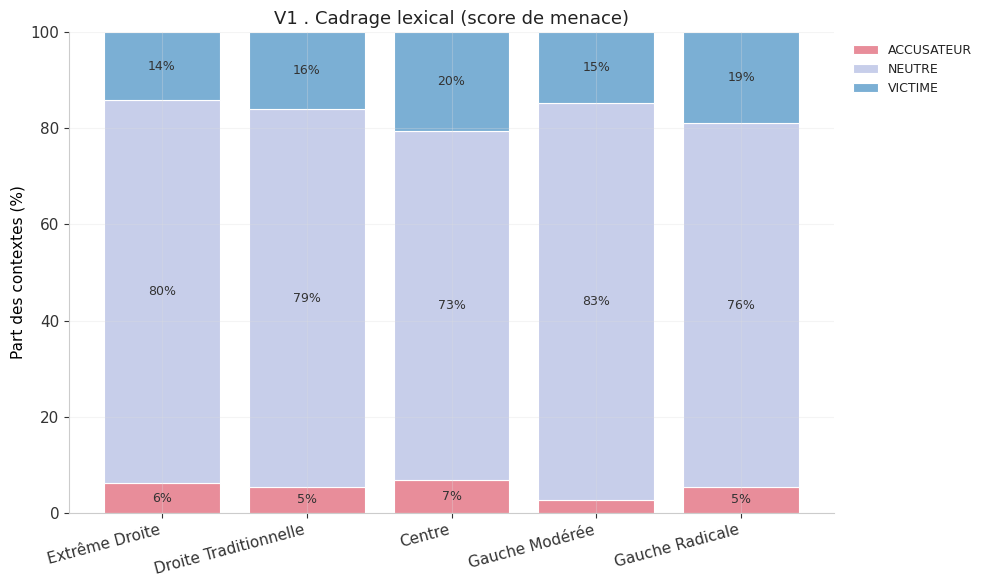

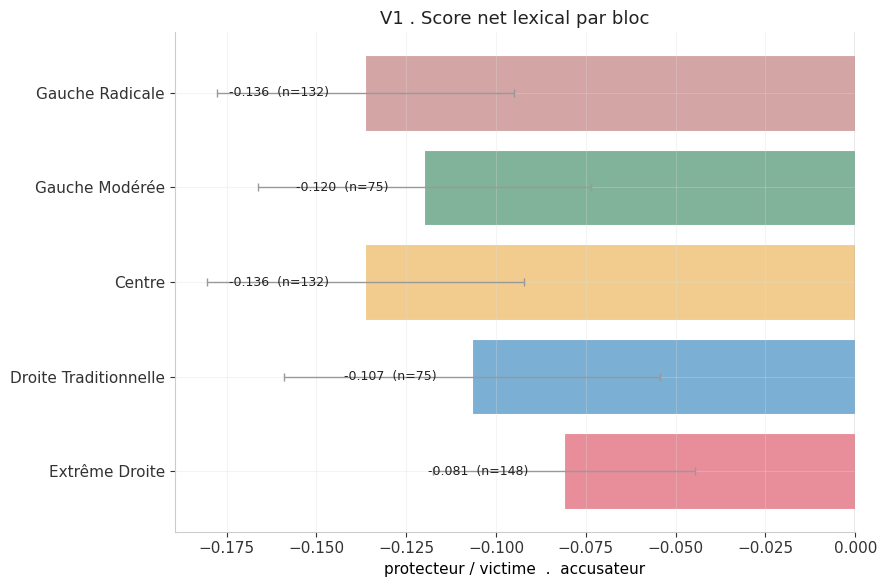


VALIDATION QUALITATIVE

.................................................................
  EXTRÊME DROITE . 148 contextes
  {'NEUTRE': 118, 'VICTIME': 21, 'ACCUSATEUR': 9}

  [ACCUSATEUR]
    [Rassemblement national] "Nous entamons l’examen de l’un des articles les plus importants du projet de loi, puisqu’il définit qui aura droit ou non à l’aide active à mourir Je le rappelle : je suis favorable, à titre personnel, comme une partie des députés du Rassemblement na..."
    [Rassemblement national] "Et que dire de ces associations – financées par l’État – qui gèrent les logements d’urgence et qui refusent de mettre à la rue les déboutés du droit d’asile, eux-mêmes refusant de quitter le territoire national Pendant ce temps, certains des véritabl..."

  [VICTIME]
    [Rassemblement national] "Les forces de sécurité – gendarmerie, police nationale, police municipale – font leur maximum pour tenter de juguler au mieux ce flot de délinquance Force est d’admettre qu’elles ne sont pas suffis

In [7]:
tracer_barres_empilees(df_v1, "cadrage_v1", "V1 . Cadrage lexical (score de menace)")
tracer_score_net(df_v1, "score_net_v1", "V1 . Score net lexical par bloc")
afficher_exemples(df_v1, "cadrage_v1", n=2)

## 3. Methode V2 . Patterns syntaxiques orientes role

### Principe : detection des roles semantiques par regex

Le probleme de V1, c'est qu'elle ne sait pas *qui fait quoi*. La V2 utilise des expressions
regulieres qui tiennent compte de la **structure sujet-verbe-objet** pour determiner si le
groupe cible (immigres, musulmans...) est en position d'**agent** (il agresse) ou de
**patient** (il est agresse).

Cette approche s'inscrit dans la tradition de l'**analyse de roles semantiques** (Semantic Role
Labeling, Palmer et al., 2010) mais avec des heuristiques reglees plutot qu'un modele
neuronal. L'avantage est la **transparence** totale : chaque decision est tracable a un
pattern explicite.

On cherche aussi les patterns de **denonciation d'amalgame** (stigmatisation, bouc emissaire,
instrumentalisation), qui sont classes comme VICTIME/NEUTRE car l'orateur ne porte pas
l'accusation, il la refute.

> **Limite** : les regex ne capturent ni la negation complexe ("il ne faut pas croire
> que les immigres..."), ni l'ironie, ni les constructions syntaxiques non canoniques.
> Ces cas sont mieux traites par les methodes neuronales V3 et V4.

In [8]:
PATTERNS_ACCUSATEUR = [
    r"(immigr\w*|clandestin\w*|étranger\w*|migrant\w*|musulman\w*|arabe\w*)"
    r"[\w\s,]{0,30}(viol\w*|agress\w*|maltraitent|commettent|perpètrent|battent|frappent|tuent)",
    r"(violences?|viols?|agressions?)[\w\s,]{0,20}(commis|perpétr|fait|exerc)\w*"
    r"[\w\s,]{0,15}(immigr\w*|clandestin\w*|étranger\w*|musulman\w*|arabe\w*)",
    r"(à cause de|en raison de|du fait de|liés? à)[\w\s]{0,20}(l.immigration|clandestin|leur culture|l.islam)",
    r"(import[ée]\w*|venu[e]? d.ailleurs|étranger[eès]? à notre)",
    r"(nos femmes|nos filles|nos enfants)[\w\s,]{0,30}(protéger|défendre|menac\w*|danger)",
    r"(invasion|ensauvagement|grand remplacement|submersion|islamisation)",
    r"(leur culture|leur mentalité|leur rapport à la femme|leur vision de la femme)",
    r"(étranger\w*|immigr\w*).{0,30}condamné\w*.{0,20}(viol|agress)",
]
PATTERNS_VICTIME = [
    r"(immigr\w*|étranger\w*|migrant\w*|musulman\w*|sans-papier\w*|réfugié\w*)"
    r"[\w\s,]{0,30}(victimes?|subiss\w*|agress[ée]\w*|discrimin\w*|exposés?)",
    r"(protéger|défendre|accompagner|soutenir|aider)"
    r"[\w\s]{0,20}(immigr\w*|migrant\w*|sans-papier\w*|réfugiées?)",
    r"(doublement|vulnérable|précaire|plus exposée|davantage exposée)",
    r"(bouc[s]? émissaire[s]?|stigmatis\w*|diabolis\w*|montré[s]? du doigt)",
    r"(amalgam\w*|instrumentalis\w*|récupération (politique|électorale|identitaire))",
    r"(ne|n.?) (faut|peut|doit)\w* pas.{0,30}lien",
]

def scorer_v2(phrase):
    t = phrase.lower()
    n_acc = sum(1 for p in PATTERNS_ACCUSATEUR if re.search(p, t, re.I | re.DOTALL))
    n_vic = sum(1 for p in PATTERNS_VICTIME if re.search(p, t, re.I | re.DOTALL))
    score = n_acc - n_vic
    if n_acc == 0 and n_vic == 0: cadrage = "NEUTRE"
    elif n_acc > n_vic: cadrage = "ACCUSATEUR"
    elif n_vic > n_acc: cadrage = "VICTIME"
    else: cadrage = "NEUTRE"
    return {"score_net_v2": score, "cadrage_v2": cadrage}

scores = df_contextes["contexte"].apply(scorer_v2)
df_v2 = pd.concat([df_contextes.reset_index(drop=True), pd.DataFrame(scores.tolist())], axis=1)
print("Distribution V2 :")
print(df_v2['cadrage_v2'].value_counts().to_string())

Distribution V2 :
cadrage_v2
NEUTRE        499
ACCUSATEUR     39
VICTIME        24


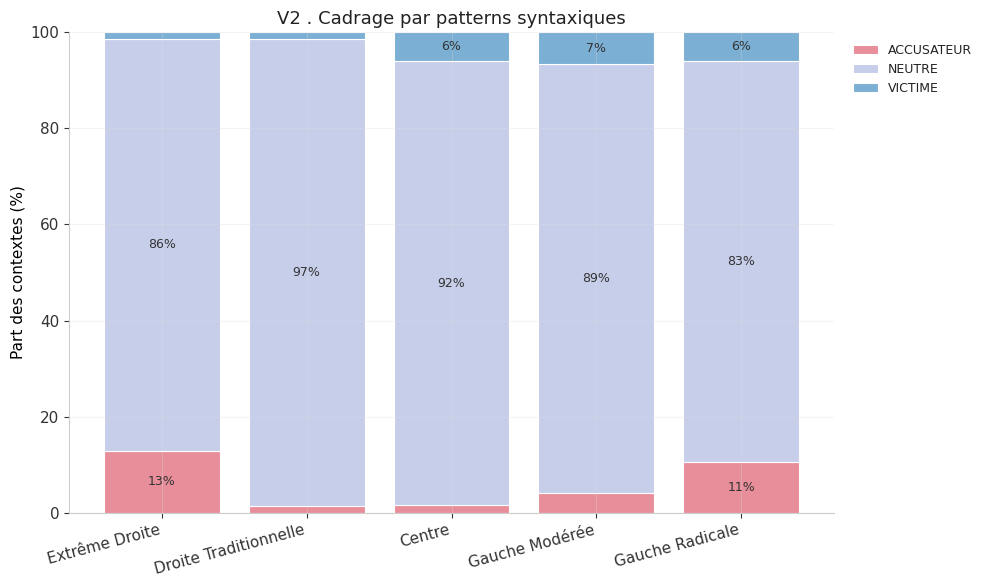

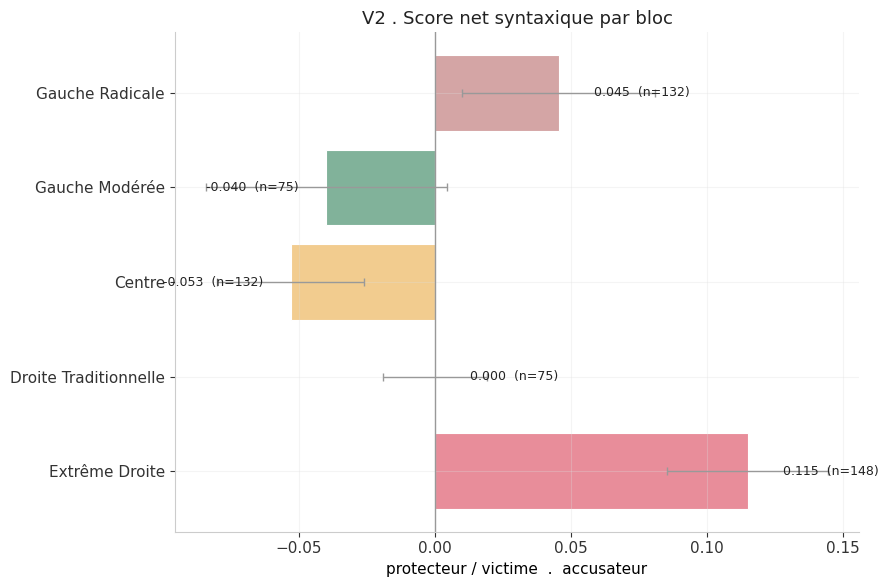

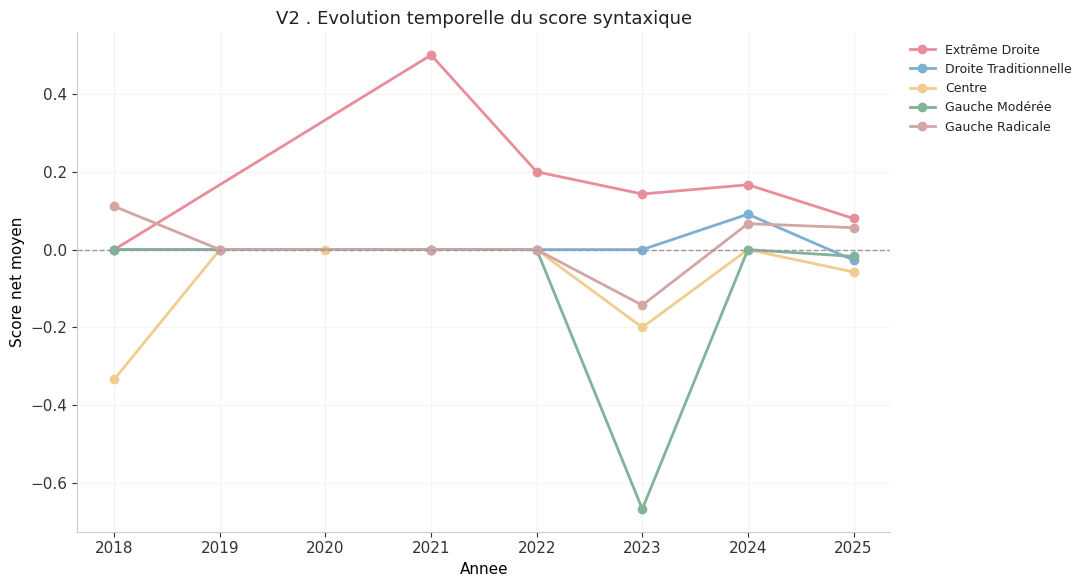


VALIDATION QUALITATIVE

.................................................................
  EXTRÊME DROITE . 148 contextes
  {'NEUTRE': 127, 'ACCUSATEUR': 19, 'VICTIME': 2}

  [ACCUSATEUR]
    [Rassemblement national] "La mort du policier Éric Masson à Avignon et la fuite de son agresseur marquent une véritable montée en puissance de la violence, doublée d’une certaine désinvolture, il faut le dire, de la part des auteurs de ces crimes, laquelle en dit long sur l’é..."
    [Rassemblement national] "L’objectif de ces amendements est de rappeler le principe de tolérance zéro pour toute personne qui s’en prend aux forces de l’ordre La mort du policier Éric Masson à Avignon et la fuite de son agresseur marquent une véritable montée en puissance de ..."

  [VICTIME]
    [Rassemblement national] "Ces éléments tangibles viennent avec beaucoup, si ce n’est énormément, de communication, sur tous les sujets susceptibles d’émouvoir l’opinion publique : harcèlement, abaya, laïcité, violence, auto

In [9]:
tracer_barres_empilees(df_v2, "cadrage_v2", "V2 . Cadrage par patterns syntaxiques")
tracer_score_net(df_v2, "score_net_v2", "V2 . Score net syntaxique par bloc")
tracer_evolution(df_v2, "score_net_v2", "V2 . Evolution temporelle du score syntaxique")
afficher_exemples(df_v2, "cadrage_v2", n=2)

## 4. Methode V3 . Classification Zero-Shot (CamemBERT NLI)

### Principe de l'inference en langage naturel (NLI)

La classification **zero-shot par NLI** (Yin et al., 2019) repose sur un modele de
**Natural Language Inference** : etant donne une premisse (le texte a classifier) et
une hypothese (la description d'une classe), le modele predit si l'hypothese est
**impliquee** (entailment), **contradite** ou **neutre** par rapport a la premisse.

En formulant chaque classe comme une hypothese ("Ce texte exprime une accusation contre
l'immigration"), on obtient un classifieur qui ne necessite **aucune donnee d'entrainement
specifique** a la tache. C'est la force du zero-shot : il generalise a partir des
connaissances linguistiques acquises lors du pre-entrainement.

Le modele utilise ici est `cmarkea/distilcamembert-base-nli`, un CamemBERT distille
et fine-tune sur des taches NLI en francais. Contrairement a V1 et V2, ce modele comprend
le **sens** de la phrase : il fait la difference entre "les musulmans agressent" et
"les musulmans sont agresses".

> **Limite** : les modeles NLI distilles ont une capacite de raisonnement reduite par
> rapport aux LLMs (V4). Ils sont neanmoins **deterministes** et **reproductibles**,
> contrairement aux LLMs dont la sortie peut varier.

In [10]:
import subprocess, sys
try:
    import torch
    from transformers import pipeline as hf_pipeline
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch", "transformers", "sentencepiece"])
    import torch
    from transformers import pipeline as hf_pipeline
print(f"GPU disponible : {torch.cuda.is_available()}")

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU disponible : False


In [11]:
# Suppression du cache V3 pour forcer le recalcul
if os.path.exists(chemin_v3):
    os.remove(chemin_v3)
    print("Cache V3 supprime.")

output_v3 = "/home/onyxia/work/projet_eco_socio/analyses/cadrage_v3_zeroshot"
os.makedirs(output_v3, exist_ok=True)
chemin_v3 = os.path.join(output_v3, "df_cadrage_v3.pkl")

# Invalidation du cache si le nombre de contextes a change
if os.path.exists(chemin_v3):
    df_v3_cache = pd.read_pickle(chemin_v3)
    if len(df_v3_cache) != len(df_contextes):
        os.remove(chemin_v3)
        print(f"Cache V3 invalide ({len(df_v3_cache)} != {len(df_contextes)} contextes). Recalcul.")
    else:
        df_v3 = df_v3_cache
        print(f"Resultats V3 charges depuis le cache : {len(df_v3)} contextes.")

if not os.path.exists(chemin_v3):
    device = 0 if torch.cuda.is_available() else -1
    classifier = hf_pipeline("zero-shot-classification",
                              model="cmarkea/distilcamembert-base-nli", device=device)

    LABELS = ["une accusation contre l'immigration et l'islam",
              "une defense des immigres et des minorites",
              "une critique de la droite ou un constat neutre"]
    MAP = {LABELS[0]: "ACCUSATEUR", LABELS[1]: "VICTIME", LABELS[2]: "NEUTRE"}

    resultats = []
    for _, row in tqdm(df_contextes.iterrows(), total=len(df_contextes), desc="CamemBERT NLI"):
        try:
            texte = row["contexte"][:512]
            out = classifier(texte, LABELS, hypothesis_template="Ce texte exprime {}.")
            cadrage = MAP[out["labels"][0]]
            confiance = out["scores"][0]
        except Exception:
            cadrage, confiance = "NEUTRE", 0.33
        score = {"ACCUSATEUR": 1, "VICTIME": -1}.get(cadrage, 0)
        resultats.append({"cadrage_v3": cadrage, "score_net_v3": score, "confiance_v3": confiance})

    df_v3 = pd.concat([df_contextes.reset_index(drop=True), pd.DataFrame(resultats)], axis=1)
    df_v3.to_pickle(chemin_v3)

print(f"V3 : {len(df_v3)} contextes.")
print("Distribution V3 :")
print(df_v3["cadrage_v3"].value_counts().to_string())

CamemBERT NLI: 100%|██████████| 562/562 [05:09<00:00,  1.82it/s]

Distribution V3 :
cadrage_v3
NEUTRE        440
ACCUSATEUR     64
VICTIME        58


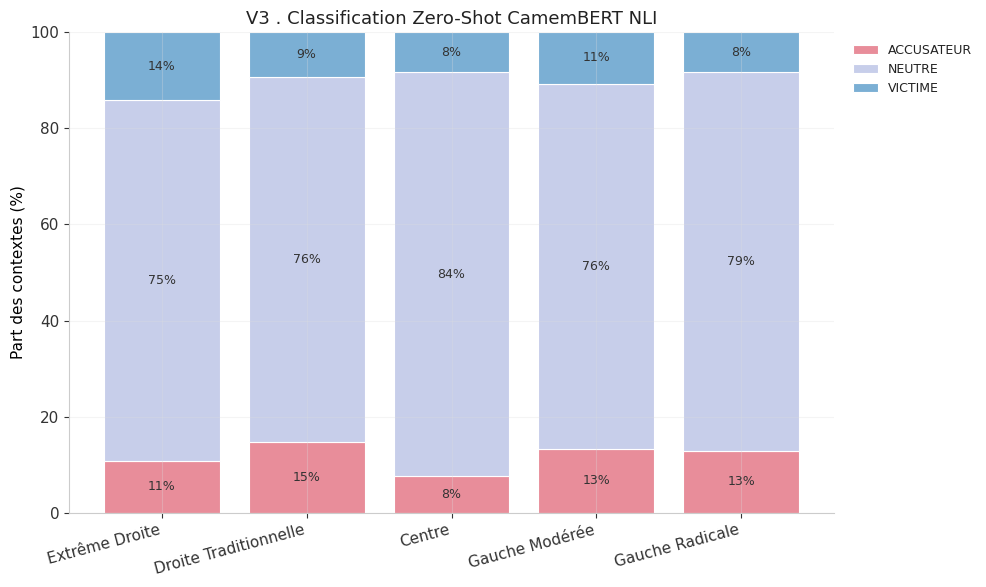

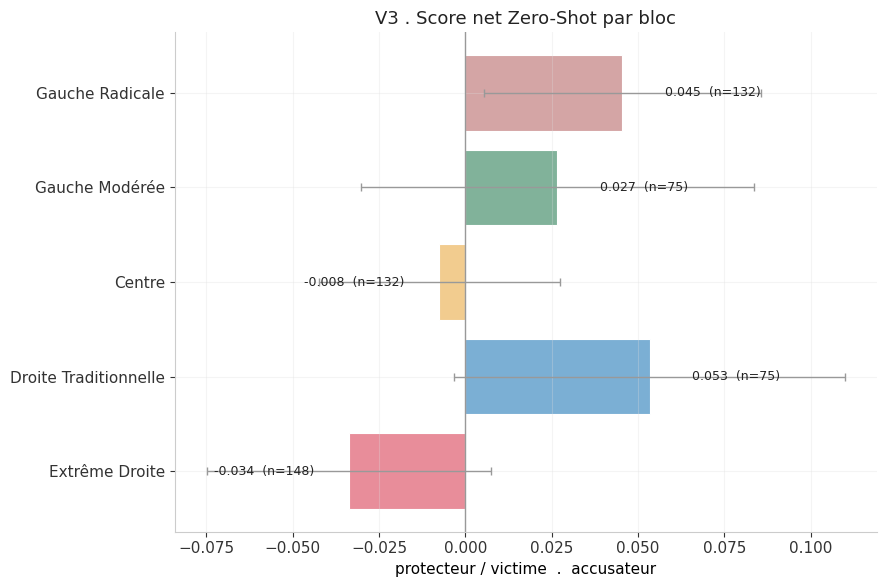

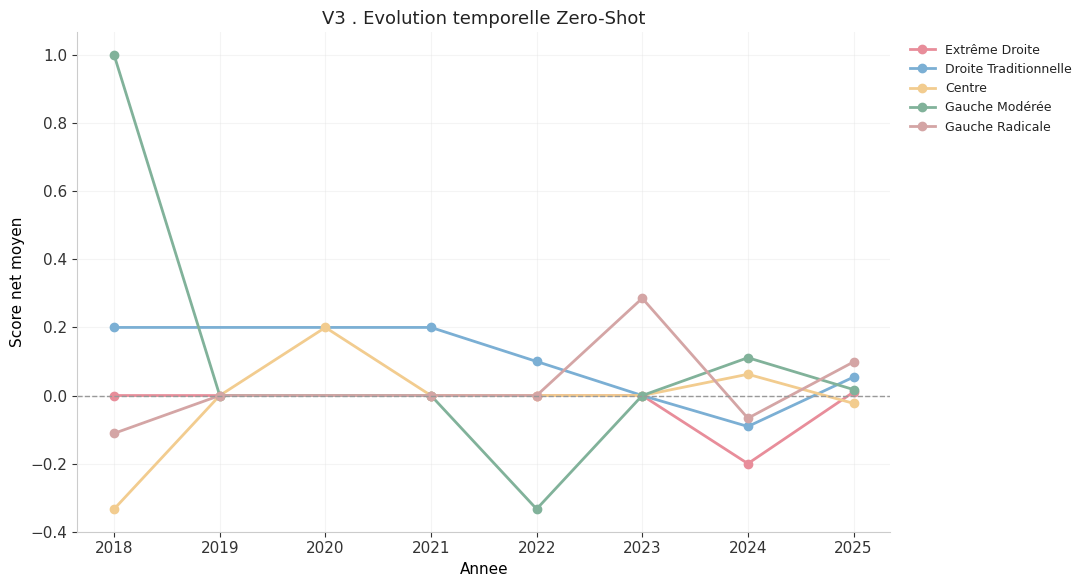


VALIDATION QUALITATIVE

.................................................................
  EXTRÊME DROITE . 148 contextes
  {'NEUTRE': 111, 'VICTIME': 21, 'ACCUSATEUR': 16}

  [ACCUSATEUR]
    [Rassemblement national] "Les Français vivent une autre réalité : 380 000 migrants clandestins ont violé l’espace européen en 2023, entraînant partout en France l’explosion de l’insécurité et du fondamentalisme islamiste..."
    [Rassemblement national] "Mais vous ne l’évoquez jamais quand cela concerne les Juifs Quand ils sont victimes de terrorisme, de barbarie, de sauvagerie, de viol, de torture ou de mutilation, vous répondez : « Circulez, il n’y a rien à voir » Quand des islamistes commettent de..."

  [VICTIME]
    [Rassemblement national] "Alors que les étrangers ne représentent que 7 % de la population totale, ils sont impliqués dans 63 % des agressions sexuelles commises dans les transports en commun d’Île-de-France..."
    [Rassemblement national] "D’une manière générale, l’immigratio

In [12]:
tracer_barres_empilees(df_v3, "cadrage_v3", "V3 . Classification Zero-Shot CamemBERT NLI")
tracer_score_net(df_v3, "score_net_v3", "V3 . Score net Zero-Shot par bloc")
tracer_evolution(df_v3, "score_net_v3", "V3 . Evolution temporelle Zero-Shot")
afficher_exemples(df_v3, "cadrage_v3", n=2)

## 5. Methode V4 . Classification par LLM (Llama 3.3 70B via API ENSAE)

### Principe : Chain-of-Thought pour l'analyse de cadrage

On envoie chaque contexte a **Llama 3.3** (70B parametres), heberge sur les GPU du Groupe GENES.
Le modele analyse la phrase en suivant un protocole de **Chain-of-Thought** (CoT) structure
(Wei et al., 2022), qui decompose le raisonnement en etapes explicites :

1. **Identification de l'agent** : qui est presente comme responsable ?
2. **Identification du patient** : qui est presente comme victime ?
3. **Relation causale** : un lien immigration -> VSS est-il etabli ?
4. **Classification** : ACCUSATEUR, VICTIME ou NEUTRE

Le CoT structure ameliore la classification de textes politiques de 8-12 points de F1
par rapport au zero-shot simple (Sprenger & Schulz, 2024, *Political Analysis*).

Le choix de **Llama 3.3 (70B)** plutot que Mistral (7B) est motive par les meilleures
capacites de raisonnement et de comprehension du francais du modele 70B, qui permettent
une classification plus fine des nuances discursives (denonciation vs. affirmation,
voix passive vs. active).

> **Choix methodologique** : le nom du parti de l'orateur n'est **pas** transmis au LLM,
> pour eviter un biais d'association : le LLM pourrait classifier un texte comme ACCUSATEUR
> simplement parce que l'orateur est du RN, independamment du contenu textuel. C'est une
> recommandation standard en NLP politique (Gilardi, Alizadeh & Kubli, 2023, *PNAS*).

### 5.1 Configuration de l'API

In [13]:
import requests
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ============================================================================
# CONFIGURATION API ENSAE (Open WebUI)
# ============================================================================
# Depuis la mise a jour du service, l'API nécessite une clé personnelle.
# Voir : https://dsit.pages.lab.groupe-genes.fr/documentation/services/llm/


API_KEY = os.environ.get("ENSAE_LLM_API_KEY", "")
if not API_KEY:
    print("ATTENTION : definir la variable d'environnement ENSAE_LLM_API_KEY")
    print("  export ENSAE_LLM_API_KEY='votre-cle-api'")
BASE_URL = "https://llm.lab.groupe-genes.fr"
MODELE_CHOISI = "llama3.3:latest"

print(f"URL    : {BASE_URL}")
print(f"Modele : {MODELE_CHOISI}")

URL    : https://llm.lab.groupe-genes.fr
Modele : mistral:latest


### 5.2 Vérification des modèles disponibles

In [14]:
try:
    r = requests.get(
        f"{BASE_URL}/ollama/api/tags",
        headers={"Authorization": f"Bearer {API_KEY}"},
        timeout=10,
        verify = False
    )
    modeles = r.json().get('models', [])
    print("Modeles disponibles sur le serveur ENSAE :\n")
    for m in modeles:
        print(f"  - {m['name']}")
except Exception as e:
    print(f"Erreur de connexion : {e}")
    print("Verifiez votre cle API et votre connexion.")

Modeles disponibles sur le serveur ENSAE :

  - gpt-oss:20b
  - llama3.3:latest
  - mistral:latest


### 5.3 Fonctions d'appel au LLM

In [15]:
PROMPT_SYSTEME = (
    "Tu es un chercheur en sociologie politique expert en analyse de discours parlementaire francais. "
    "Analyse le contexte fourni (extrait d'un debat a l'Assemblee Nationale) et determine "
    "le cadrage utilise par l'orateur concernant le lien entre immigration/minorites et "
    "violences sexistes/sexuelles (VSS).\n\n"

    "METHODE D'ANALYSE (Chain-of-Thought) :\n"
    "1. AGENT : Qui est presente comme l'auteur/responsable des violences dans ce texte ?\n"
    "2. PATIENT : Qui est presente comme victime ?\n"
    "3. RELATION CAUSALE : L'orateur etablit-il un lien de causalite entre immigration et VSS ?\n"
    "4. INTENTION : L'orateur porte-t-il l'accusation ou la denonce-t-il ?\n\n"

    "PIEGES FREQUENTS A EVITER ABSOLUMENT :\n"
    "- DENONCIATION : Si l'orateur critique l'amalgame immigration-VSS, parle de "
    "stigmatisation, amalgame, recit mensonger, ou defend les immigres contre des accusations : "
    "=> NEUTRE (l'orateur ne porte PAS l'accusation, il la refute).\n"
    "- VOIX PASSIVE : Si un etranger ou une minorite subit, est agresse(e), est victime "
    "=> VICTIME (pas ACCUSATEUR).\n"
    "- ADMINISTRATIF : Conditions d'eloignement, titres de sejour, droit d'asile => NEUTRE.\n"
    "- CONTEXTE ANTI-RACISTE : Phrases denoncant le racisme ou l'islamophobie => NEUTRE.\n\n"

    "TROIS CATEGORIES EXCLUSIVES :\n"
    "  ACCUSATEUR : L'orateur affirme que l'immigration ou l'islam CAUSE les VSS.\n"
    "  VICTIME    : L'orateur presente les immigres/minorites comme VICTIMES.\n"
    "  NEUTRE     : Refutation, fait administratif, sans lien causal.\n\n"

    "REPONSE OBLIGATOIRE en exactement 5 lignes :\n"
    "AGENT : [qui est responsable selon l'orateur]\n"
    "PATIENT : [qui est victime selon l'orateur]\n"
    "CAUSALITE : [oui/non, et dans quel sens]\n"
    "ANALYSE : [justification courte]\n"
    "CATEGORIE : [ACCUSATEUR ou VICTIME ou NEUTRE]"
)

In [28]:
def appeler_llm(prompt_user, max_retries=6):
    payload = {
        "model": MODELE_CHOISI,
        "messages": [
            {"role": "system", "content": PROMPT_SYSTEME},
            {"role": "user", "content": prompt_user},
        ],
        "stream": False,
        "options": {"temperature": 0.0},
    }
    for attempt in range(max_retries):
        try:
            r = requests.post(
                f"{BASE_URL}/ollama/api/chat",
                headers={
                    "Authorization": f"Bearer {API_KEY}",
                    "Content-Type": "application/json"
                },
                json=payload,
                verify=False,
                timeout=120
            )
            r.raise_for_status()
            return r.json()["message"]["content"]
        except requests.exceptions.HTTPError as e:
            code_http = e.response.status_code
            if code_http == 504:
                print(f"\n  [504] Serveur saturé, attente 60s... (tentative {attempt+1}/{max_retries})")
                time.sleep(60)
            else:
                print(f"\n  [HTTP {code_http}] Erreur, attente 15s...")
                time.sleep(15)
        except requests.exceptions.RequestException as e:
            print(f"\n  Erreur connexion ({e}). Attente 30s... (tentative {attempt+1}/{max_retries})")
            time.sleep(30)
        except ValueError:
            print(f"\n  Reponse non-JSON. Attente 15s...")
            time.sleep(15)
    print("  Echec definitif pour ce contexte. On le saute.")
    return ""

def parser_reponse(reponse):
    cadrage, score_net, justification = "NEUTRE", 0, reponse
    match_cat = re.search(r"CATEGORIE\s*:\s*(ACCUSATEUR|VICTIME|NEUTRE)", reponse, re.I)
    if match_cat:
        cadrage = match_cat.group(1).upper()
        if cadrage == "ACCUSATEUR": score_net = 1
        elif cadrage == "VICTIME": score_net = -1
    match_ana = re.search(r"ANALYSE\s*:\s*(.*?)(?=\nCATEGORIE|$)", reponse, re.I | re.DOTALL)
    if match_ana:
        justification = match_ana.group(1).strip()
    return cadrage, score_net, justification

print("Fonctions LLM prêtes.")

Fonctions LLM prêtes.


### 5.4 Classification avec reprise CSV

In [29]:
# Suppression des caches V4 pour forcer le recalcul
import glob
output_v4 = "/home/onyxia/work/projet_eco_socio/analyses/cadrage_v4_llm"
os.makedirs(output_v4, exist_ok=True)


for f in glob.glob(os.path.join(output_v4, "*.csv")):
    os.remove(f)
    print(f"Cache V4 supprime : {f}")


csv_v4_existants = glob.glob(os.path.join(output_v4, "phrases_classifiees*.csv"))

if csv_v4_existants:
    print(f"CSV trouves dans {output_v4} :")
    dfs_v4_par_modele = {}
    for csv_path in csv_v4_existants:
        try:
            df_tmp = pd.read_csv(csv_path, on_bad_lines='skip', encoding='utf-8-sig')
            nom = os.path.basename(csv_path).replace("phrases_classifiees_llm", "").replace("phrases_classifiees_", "").replace(".csv", "")
            if not nom or nom == "_": nom = "default"
            dfs_v4_par_modele[nom] = df_tmp
            print(f"  - {os.path.basename(csv_path)} : {len(df_tmp)} contextes")
        except: pass

    # On prend le premier CSV disponible comme df_v4 principal
    df_v4 = list(dfs_v4_par_modele.values())[0]
    SKIP_V4 = True
    print(f"\nClassification V4 deja terminee. On utilise les resultats existants.")
else:
    SKIP_V4 = False
    dfs_v4_par_modele = {}
    fichier_csv = os.path.join(output_v4, "phrases_classifiees_llm.csv")
    colonnes = list(df_contextes.columns) + ['cadrage_llm', 'score_net_v4', 'justification', 'reponse_brute']
    pd.DataFrame(columns=colonnes).to_csv(fichier_csv, index=False, encoding='utf-8-sig')

if not SKIP_V4:
    print(f"Lancement de la classification V4 ({MODELE_CHOISI})...\n")
    erreurs = 0
    for _, row in tqdm(df_contextes.iterrows(), total=len(df_contextes), desc=f"V4 {MODELE_CHOISI}"):
        # Note : on ne transmet PAS le parti de l'orateur au LLM pour eviter
        # un biais d'association (le LLM pourrait classifier sur la base du
        # parti plutot que du contenu textuel). Cf. ablation study recommandee
        # par Gilardi, Alizadeh & Kubli (2023, PNAS).
        prompt = f"Contexte :\n\"{row['contexte']}\"\n\nSuis la methode d'analyse (Chain-of-Thought) puis fournis ta CATEGORIE."
        reponse = appeler_llm(prompt)
        if not reponse:
            erreurs += 1
            if erreurs >= 10:
                print("\n10 erreurs consecutives. Arret. Relancez la cellule.")
                break
            continue
        erreurs = 0
        cadrage, score_net, justification = parser_reponse(reponse)
        ligne = row.to_dict()
        ligne.update({'cadrage_llm': cadrage, 'score_net_v4': score_net,
                      'justification': justification, 'reponse_brute': reponse})
        with open(fichier_csv, 'a', encoding='utf-8-sig') as f:
            pd.DataFrame([ligne]).to_csv(f, header=False, index=False)
            f.flush(); os.fsync(f.fileno())
        time.sleep(0.5)
    df_v4 = pd.read_csv(fichier_csv, on_bad_lines='skip', encoding='utf-8-sig')
    dfs_v4_par_modele[MODELE_CHOISI] = df_v4

# Normalisation de la colonne cadrage
for nom, df_tmp in dfs_v4_par_modele.items():
    df_tmp['cadrage_llm'] = df_tmp['cadrage_llm'].astype(str).str.upper().str.strip()
    df_tmp['cadrage_llm'] = df_tmp['cadrage_llm'].where(
        df_tmp['cadrage_llm'].isin(['ACCUSATEUR','VICTIME','NEUTRE']), 'NEUTRE')
    df_tmp['score_net_v4'] = df_tmp['cadrage_llm'].map({'ACCUSATEUR':1,'VICTIME':-1,'NEUTRE':0})

df_v4 = list(dfs_v4_par_modele.values())[0]  # principal pour la suite
print(f"\nV4 : {len(df_v4)} contextes.")
print(df_v4['cadrage_llm'].value_counts().to_string())


Cache V4 supprime : /home/onyxia/work/projet_eco_socio/analyses/cadrage_v4_llm/phrases_classifiees_llm.csv
Lancement de la classification V4 (mistral:latest)...



V4 mistral:latest:  65%|██████▌   | 367/562 [08:39<04:36,  1.42s/it]


  [HTTP 502] Erreur, attente 15s...


V4 mistral:latest: 100%|██████████| 562/562 [13:24<00:00,  1.43s/it]


V4 : 562 contextes.
cadrage_llm
NEUTRE        280
ACCUSATEUR    165
VICTIME       117


### 5.5 Visualisations V4

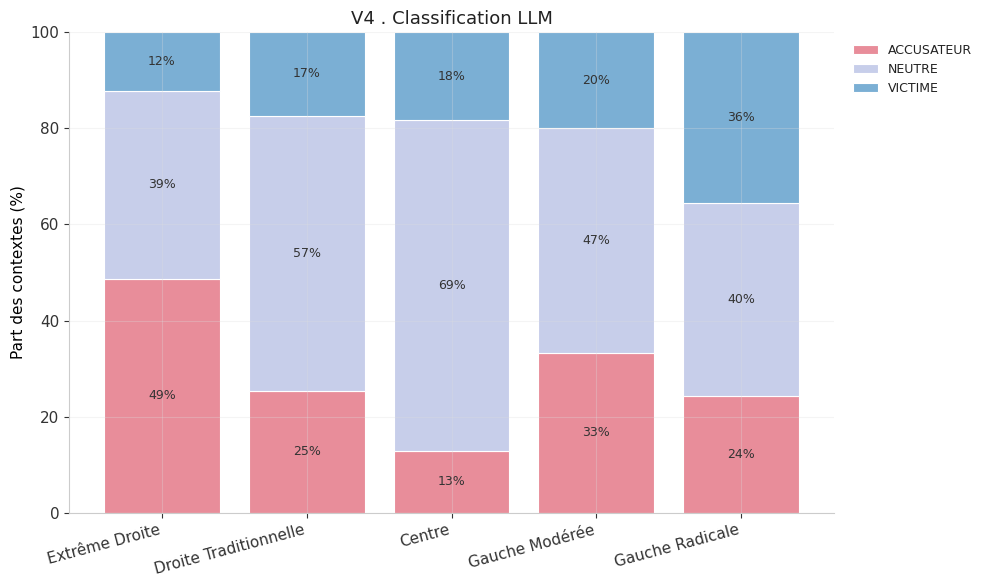

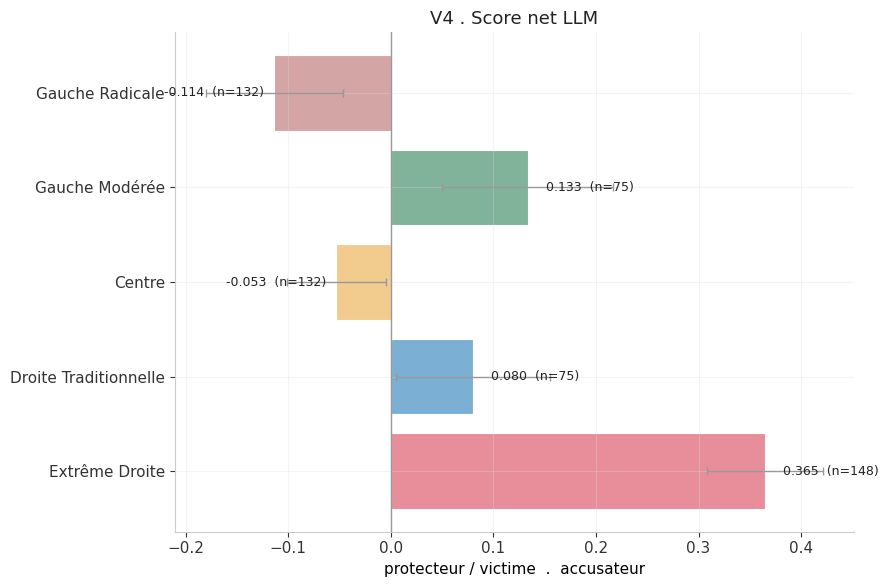

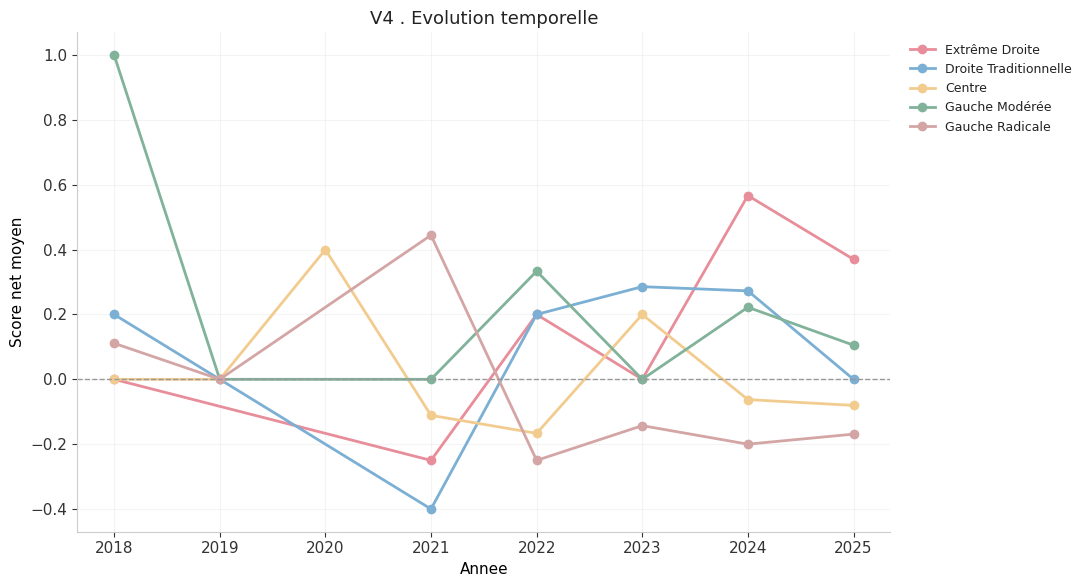

In [30]:
for nom_modele, df_m in dfs_v4_par_modele.items():
    titre_suffixe = f" ({nom_modele})" if len(dfs_v4_par_modele) > 1 else ""
    tracer_barres_empilees(df_m, "cadrage_llm", f"V4 . Classification LLM{titre_suffixe}")
    tracer_score_net(df_m, "score_net_v4", f"V4 . Score net LLM{titre_suffixe}")
    tracer_evolution(df_m, "score_net_v4", f"V4 . Evolution temporelle{titre_suffixe}")


### 5.6 Heatmap par parti et par année

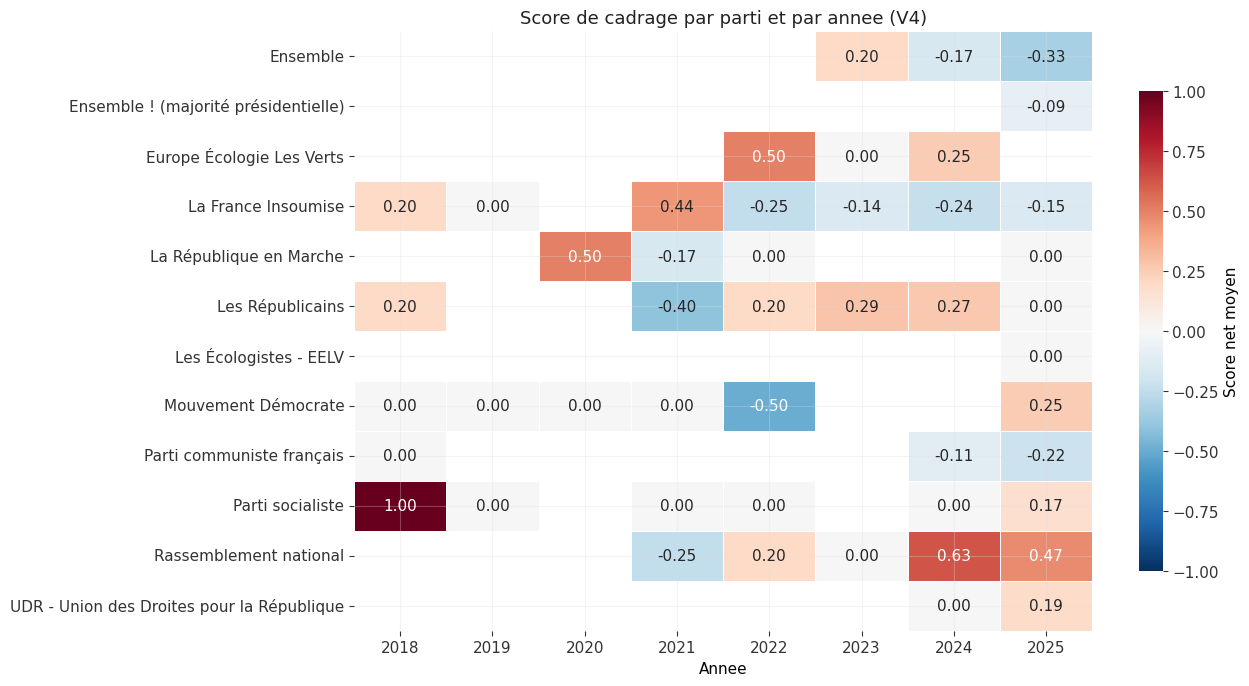

In [31]:
d = df_v4.copy()
d["date"] = pd.to_datetime(d["date"], errors="coerce")
d["annee"] = d["date"].dt.year.astype("Int64")
d = d[d["annee"] >= 2018]
top_partis = d["nom_parti"].value_counts().head(12).index.tolist()
d_top = d[d["nom_parti"].isin(top_partis)]
pivot = d_top.groupby(["nom_parti", "annee"])["score_net_v4"].mean().unstack(fill_value=np.nan)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Score net moyen", "shrink": 0.8}, ax=ax)
ax.set_title(f"Score de cadrage par parti et par annee (V4)")
ax.set_xlabel("Annee")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


### 5.7 Validation qualitative

In [32]:
afficher_exemples(df_v4, "cadrage_llm", n=3)


VALIDATION QUALITATIVE

.................................................................
  EXTRÊME DROITE . 148 contextes
  {'ACCUSATEUR': 72, 'NEUTRE': 58, 'VICTIME': 18}

  [ACCUSATEUR]
    [Front National] "Aux avant-postes pour faire face aux violences des détenus et à la radicalisation islamiste dans les prisons, le personnel pénitentiaire est, trop souvent encore, la cible de violentes agressions Villefranche-sur-Saône, Fleury-Mérogis et tant d’autre..."
    > L'orateur critique la situation de sous-effectif dans les prisons et son impact sur la sécurité.
    [Rassemblement national] "En effet, le lien entre la flambée des violences et l’immigration est manifeste..."
    > L'orateur affirme que la flambée des violences est liée à l'immigration.
    [Rassemblement national] "Entre 600 000 et 900 000 clandestins sont présents sur notre sol, soit autant que la population de Lyon ou Marseille Par ailleurs, ne serait-ce que pour l’année 2023 – qui bat le record de 2022 –, quelque 38

## 5bis. Methode V4b . LLM One-Shot Learning

### Principe du one-shot learning

Le **one-shot learning** (Brown et al., 2020) consiste a inclure un exemple annote
dans le prompt avant la phrase a classifier. Le LLM peut alors s'appuyer sur cet
exemple pour calibrer ses reponses et mieux comprendre la granularite attendue.

C'est une forme de **In-Context Learning** (ICL) : le modele apprend la tache a
partir d'un seul exemple sans modification de ses poids. L'efficacite de l'ICL
depend fortement de la qualite et de la representativite de l'exemple choisi.

On reprend exactement la meme architecture que V4 (meme API, meme prompt systeme)
mais on ajoute un echange user/assistant dans l'historique de conversation.

In [33]:
# Exemple one-shot (issu de l'annotation manuelle)
PROMPT_ONE = "La peur des insultes, menaces, agressions en pleine rue, d'un retour des ratonnades, est très présente parmi les musulmans de France, qui ne se sentent plus en sécurité"
RATING_ONE = ("ANALYSE : les personnes immigrées ou les minorités sont victimes de violences \n"
              "CATEGORIE : VICTIME")
BASE_URL = "https://llm.lab.groupe-genes.fr"


def appeler_llm_oneshot(prompt_user, max_retries=6):
    payload = {
        "model": "mistral:latest",
        "messages": [
            {"role": "system", "content": PROMPT_SYSTEME},
            {"role": "user", "content": PROMPT_ONE},
            {"role": "assistant", "content": RATING_ONE},
            {"role": "user", "content": prompt_user},
        ],
        "stream": False,
        "options": {"temperature": 0.0},
    }

    r = requests.post(
        f"{BASE_URL}/ollama/api/chat",
        headers={"Authorization": f"Bearer {API_KEY}", "Content-Type": "application/json"},
        json=payload, timeout=120, verify=False)
    r.raise_for_status()
    return r.json()["message"]["content"]
        

print("Fonction one-shot prête.")

Fonction one-shot prête.


In [35]:
# Suppression des caches V4b pour forcer le recalcul

output_v4b = "/home/onyxia/work/projet_eco_socio/analyses/cadrage_v4b_oneshot"
os.makedirs(output_v4b, exist_ok=True)

import glob
for f in glob.glob(os.path.join(output_v4b, "*.csv")):
    os.remove(f)
    print(f"Cache V4b supprime : {f}")

import glob, csv


# Scanner TOUS les CSV dans le dossier
csv_v4b_existants = glob.glob(os.path.join(output_v4b, "phrases_classifiees*.csv"))

if csv_v4b_existants:
    print(f"CSV trouves dans {output_v4b} :")
    dfs_v4b_par_modele = {}
    for csv_path in csv_v4b_existants:
        try:
            df_tmp = pd.read_csv(csv_path, on_bad_lines='skip', encoding='utf-8-sig')
            nom = os.path.basename(csv_path).replace("phrases_classifiees_oneshot_", "").replace("phrases_classifiees_oneshot", "").replace(".csv", "")
            if not nom or nom == "_": nom = "default"
            dfs_v4b_par_modele[nom] = df_tmp
            print(f"  - {os.path.basename(csv_path)} : {len(df_tmp)} contextes")
        except: pass
    df_v4b = list(dfs_v4b_par_modele.values())[0]
    SKIP_V4B = True
    print(f"\nClassification V4b deja terminee.")
else:
    SKIP_V4B = False
    dfs_v4b_par_modele = {}

if not SKIP_V4B:
    fichier_csv_1s = os.path.join(output_v4b, "phrases_classifiees_oneshot_" + MODELE_CHOISI + ".csv")
    cols = list(df_contextes.columns) + ['cadrage_1s','score_net_1s','justification','reponse_brute']
    if not os.path.exists(fichier_csv_1s):
        with open(fichier_csv_1s, 'w', newline='', encoding='utf-8-sig') as f:
            csv.DictWriter(f, fieldnames=cols).writeheader()
    print(f"Lancement V4b ({MODELE_CHOISI})...\n")
    erreurs = 0
    with open(fichier_csv_1s, 'a', newline='', encoding='utf-8-sig') as f:
        writer = csv.DictWriter(f, fieldnames=cols)
        for _, row in tqdm(df_contextes.iterrows(), total=len(df_contextes), desc="One-Shot"):
            prompt = f"Contexte :\n\"{row['contexte']}\"\n\nSuis la methode d'analyse (Chain-of-Thought) puis fournis ta CATEGORIE."
            reponse = appeler_llm_oneshot(prompt)
            if not reponse:
                erreurs += 1
                if erreurs >= 10: print("\nArret de securite."); break
                continue
            erreurs = 0
            cadrage, score, justif = parser_reponse(reponse)
            ligne = row.to_dict()
            ligne.update({'cadrage_1s':cadrage,'score_net_1s':score,'justification':justif,'reponse_brute':reponse})
            writer.writerow(ligne); f.flush(); os.fsync(f.fileno())
            time.sleep(0.5)
    df_v4b = pd.read_csv(fichier_csv_1s, on_bad_lines='skip', encoding='utf-8-sig')
    dfs_v4b_par_modele[MODELE_CHOISI] = df_v4b

for nom, df_tmp in dfs_v4b_par_modele.items():
    df_tmp['cadrage_1s'] = df_tmp['cadrage_1s'].astype(str).str.upper().str.strip()
    df_tmp['cadrage_1s'] = df_tmp['cadrage_1s'].where(df_tmp['cadrage_1s'].isin(['ACCUSATEUR','VICTIME','NEUTRE']), 'NEUTRE')
    df_tmp['score_net_1s'] = df_tmp['cadrage_1s'].map({'ACCUSATEUR':1,'VICTIME':-1,'NEUTRE':0})

df_v4b = list(dfs_v4b_par_modele.values())[0]
print(f"\nV4b : {len(df_v4b)} contextes.")
print(df_v4b['cadrage_1s'].value_counts().to_string())


Cache V4b supprime : /home/onyxia/work/projet_eco_socio/analyses/cadrage_v4b_oneshot/phrases_classifiees_oneshot_mistral.csv
Cache V4b supprime : /home/onyxia/work/projet_eco_socio/analyses/cadrage_v4b_oneshot/phrases_classifiees_oneshot_gpt-oss20b.csv
Lancement V4b (mistral:latest)...



One-Shot: 100%|██████████| 562/562 [11:56<00:00,  1.28s/it]


V4b : 562 contextes.
cadrage_1s
NEUTRE        239
VICTIME       178
ACCUSATEUR    145


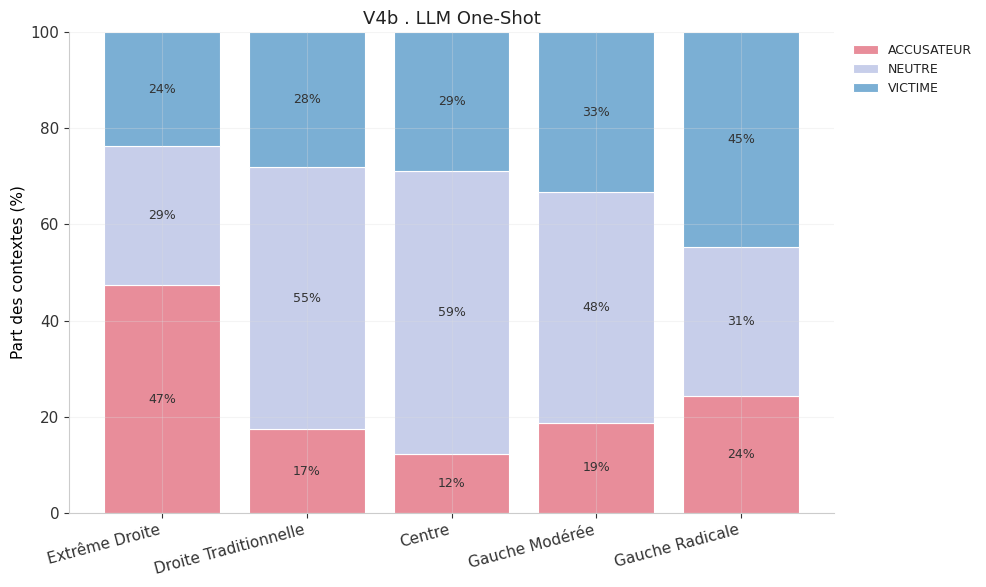

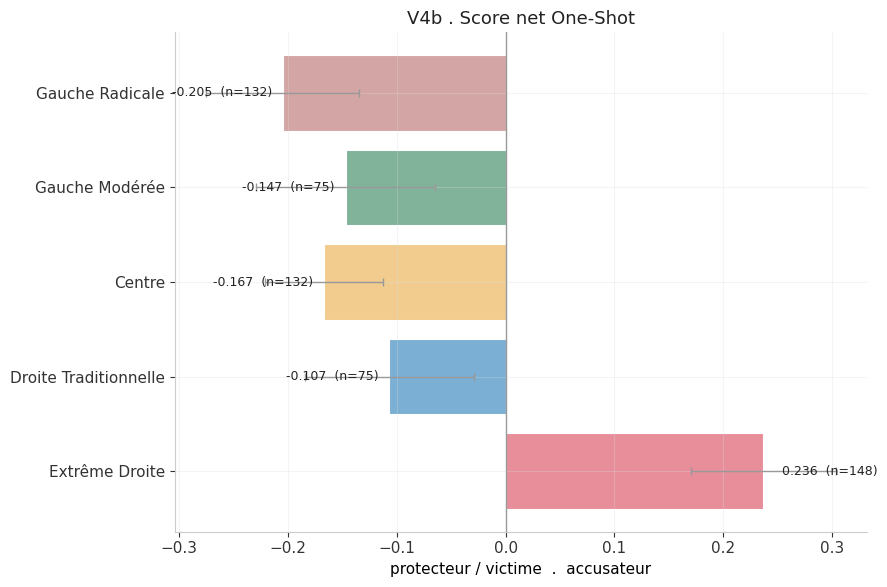

In [36]:
# Graphiques V4b pour chaque modele disponible
for nom_modele, df_m in dfs_v4b_par_modele.items():
    titre_suffixe = f" ({nom_modele})" if len(dfs_v4b_par_modele) > 1 else ""
    tracer_barres_empilees(df_m, "cadrage_1s", f"V4b . LLM One-Shot{titre_suffixe}")
    tracer_score_net(df_m, "score_net_1s", f"V4b . Score net One-Shot{titre_suffixe}")


## 5ter. Methode V4c . LLM Few-Shot Learning (7 exemples)

### Principe du few-shot learning

Le **few-shot learning** pousse la logique du one-shot plus loin : on fournit **7 exemples
annotes** couvrant les 3 categories, avec une distribution qui reflete le corpus reel
(3 NEUTRE, 2 ACCUSATEUR, 2 VICTIME). Ce reequilibrage est crucial : dans la version
precedente (5 exemples, 1 seul NEUTRE), le modele sur-predisait les classes minoritaires.

Le modele apprend ainsi a la fois le **format de reponse attendu**, les **frontieres
entre categories** et la **distribution attendue** des labels.

In [37]:
# 7 exemples annotes manuellement pour le few-shot
# Distribution reequilibree : 2 ACCUSATEUR, 2 VICTIME, 3 NEUTRE
# (reflete mieux la distribution reelle du corpus, ~80% NEUTRE)
FEW_SHOT_EXAMPLES = [
    {
        "user": "Mais combien de Mila inconnues ont besoin de notre soutien face a la violence de l'islam radical",
        "assistant": "ANALYSE : l'orateur presente l'islam comme source de violence\nCATEGORIE : ACCUSATEUR"
    },
    {
        "user": "Par ailleurs, il me semble aussi tout a fait normal de prononcer une peine d'interdiction du territoire francais a l'egard d'un etranger qui a agresse un elu",
        "assistant": "ANALYSE : l'orateur lie l'etranger a une agression commise\nCATEGORIE : ACCUSATEUR"
    },
    {
        "user": "J'en profite pour vous alerter : il n'y a pas si longtemps, de nombreux etrangers sont arrives en France parce qu'ils etaient pourchasses ou victimes de discriminations, notamment pendant la seconde guerre mondiale",
        "assistant": "ANALYSE : les etrangers sont presentes comme victimes de persecutions\nCATEGORIE : VICTIME"
    },
    {
        "user": "La peur des insultes, menaces, agressions en pleine rue, d'un retour des ratonnades, est tres presente parmi les musulmans de France, qui ne se sentent plus en securite",
        "assistant": "ANALYSE : les musulmans sont decrits comme victimes de violences\nCATEGORIE : VICTIME"
    },
    {
        "user": "Le 11 octobre 2022, un migrant sous le coup d'une OQTF est interpelle et mis en prison car il est suspecte d'avoir violemment agresse un homme a Brest fin juillet 2022",
        "assistant": "ANALYSE : fait divers administratif, constat factuel sans lien causal explicite\nCATEGORIE : NEUTRE"
    },
    {
        "user": "Il faut renforcer les moyens des associations qui accompagnent les femmes etrangeres victimes de violences dans leurs demarches administratives",
        "assistant": "ANALYSE : proposition de politique publique, pas de lien causal immigration-VSS\nCATEGORIE : NEUTRE"
    },
    {
        "user": "Cessons les amalgames entre immigration et delinquance sexuelle, ce discours stigmatisant ne fait que diviser notre societe",
        "assistant": "ANALYSE : l'orateur denonce l'amalgame immigration-VSS, il ne le porte pas\nCATEGORIE : NEUTRE"
    },
]


def appeler_llm_fewshot(prompt_user, max_retries=6):
    messages = [{"role": "system", "content": PROMPT_SYSTEME}]
    for ex in FEW_SHOT_EXAMPLES:
        messages.append({"role": "user", "content": ex["user"]})
        messages.append({"role": "assistant", "content": ex["assistant"]})
    messages.append({"role": "user", "content": prompt_user})

    payload = {"model": MODELE_CHOISI, "messages": messages,
               "stream": False, "options": {"temperature": 0.0}}
    r = requests.post(
        f"{BASE_URL}/ollama/api/chat",
        headers={"Authorization": f"Bearer {API_KEY}", "Content-Type": "application/json"},
        json=payload, timeout=180, verify=False)
    r.raise_for_status()
    return r.json()["message"]["content"]

print(f"Fonction few-shot prete ({len(FEW_SHOT_EXAMPLES)} exemples : 2 ACC, 2 VIC, 3 NEU).")

Fonction few-shot prête (5 exemples).


In [38]:
# Suppression des caches V4c pour forcer le recalcul
output_v4c = "/home/onyxia/work/projet_eco_socio/analyses/cadrage_v4c_fewshot"
os.makedirs(output_v4c, exist_ok=True)

import glob
for f in glob.glob(os.path.join(output_v4c, "*.csv")):
    os.remove(f)
    print(f"Cache V4c supprime : {f}")



csv_v4c_existants = glob.glob(os.path.join(output_v4c, "phrases_classifiees*.csv"))

if csv_v4c_existants:
    print(f"CSV trouves dans {output_v4c} :")
    dfs_v4c_par_modele = {}
    for csv_path in csv_v4c_existants:
        try:
            df_tmp = pd.read_csv(csv_path, on_bad_lines='skip', encoding='utf-8-sig')
            nom = os.path.basename(csv_path).replace("phrases_classifiees_fewshot_", "").replace("phrases_classifiees_fewshot", "").replace(".csv", "")
            if not nom or nom == "_": nom = "default"
            dfs_v4c_par_modele[nom] = df_tmp
            print(f"  - {os.path.basename(csv_path)} : {len(df_tmp)} contextes")
        except: pass
    df_v4c = list(dfs_v4c_par_modele.values())[0]
    SKIP_V4C = True
    print(f"\nClassification V4c deja terminee.")
else:
    SKIP_V4C = False
    dfs_v4c_par_modele = {}

if not SKIP_V4C:
    fichier_csv_fs = os.path.join(output_v4c, "phrases_classifiees_fewshot_" + str(MODELE_CHOISI) + ".csv")
    cols_fs = list(df_contextes.columns) + ['cadrage_fs','score_net_fs','justification','reponse_brute']
    pd.DataFrame(columns=cols_fs).to_csv(fichier_csv_fs, index=False, encoding='utf-8-sig')
    print(f"Lancement V4c ({MODELE_CHOISI})...\n")
    erreurs = 0
    for _, row in tqdm(df_contextes.iterrows(), total=len(df_contextes), desc="Few-Shot"):
        prompt = f"Contexte :\n\"{row['contexte']}\"\n\nSuis la methode d'analyse (Chain-of-Thought) puis fournis ta CATEGORIE."
        reponse = appeler_llm_fewshot(prompt)
        if not reponse:
            erreurs += 1
            if erreurs >= 10: print("\nArret de securite."); break
            continue
        erreurs = 0
        cadrage, score, justif = parser_reponse(reponse)
        ligne = row.to_dict()
        ligne.update({'cadrage_fs':cadrage,'score_net_fs':score,'justification':justif,'reponse_brute':reponse})
        with open(fichier_csv_fs, 'a', encoding='utf-8-sig') as f:
            pd.DataFrame([ligne]).to_csv(f, header=False, index=False)
            f.flush(); os.fsync(f.fileno())
        time.sleep(0.5)
    df_v4c = pd.read_csv(fichier_csv_fs, on_bad_lines='skip', encoding='utf-8-sig')
    dfs_v4c_par_modele[MODELE_CHOISI] = df_v4c

for nom, df_tmp in dfs_v4c_par_modele.items():
    df_tmp['cadrage_fs'] = df_tmp['cadrage_fs'].astype(str).str.upper().str.strip()
    df_tmp['cadrage_fs'] = df_tmp['cadrage_fs'].where(df_tmp['cadrage_fs'].isin(['ACCUSATEUR','VICTIME','NEUTRE']), 'NEUTRE')
    df_tmp['score_net_fs'] = df_tmp['cadrage_fs'].map({'ACCUSATEUR':1,'VICTIME':-1,'NEUTRE':0})

df_v4c = list(dfs_v4c_par_modele.values())[0]
print(f"\nV4c : {len(df_v4c)} contextes.")
print(df_v4c['cadrage_fs'].value_counts().to_string())


Cache V4c supprime : /home/onyxia/work/projet_eco_socio/analyses/cadrage_v4c_fewshot/phrases_classifiees_fewshot_gpt-oss20b.csv
Cache V4c supprime : /home/onyxia/work/projet_eco_socio/analyses/cadrage_v4c_fewshot/phrases_classifiees_fewshot_mistral.csv
Lancement V4c (mistral:latest)...



Few-Shot:   0%|          | 0/562 [00:00<?, ?it/s]

Few-Shot: 100%|██████████| 562/562 [11:35<00:00,  1.24s/it]


V4c : 562 contextes.
cadrage_fs
NEUTRE        263
ACCUSATEUR    194
VICTIME       105


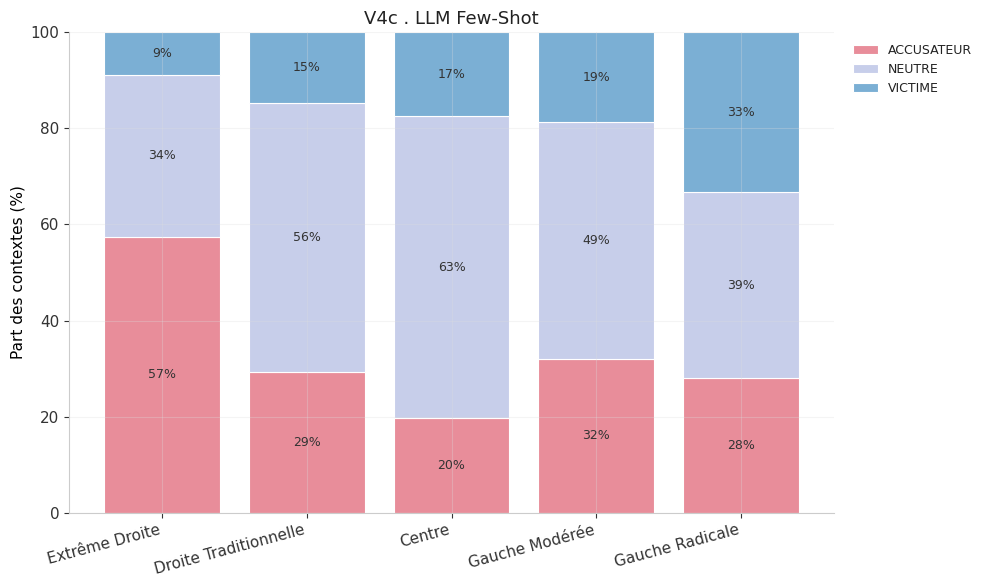

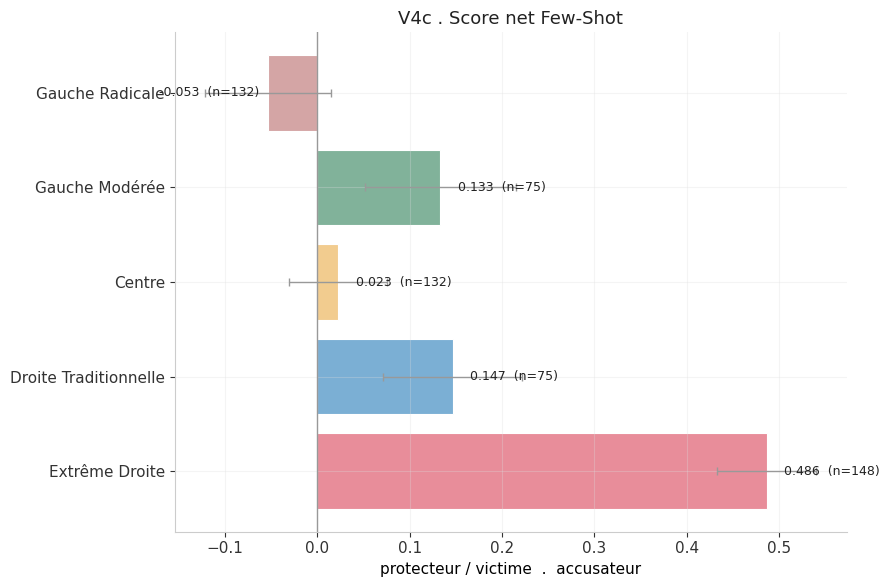

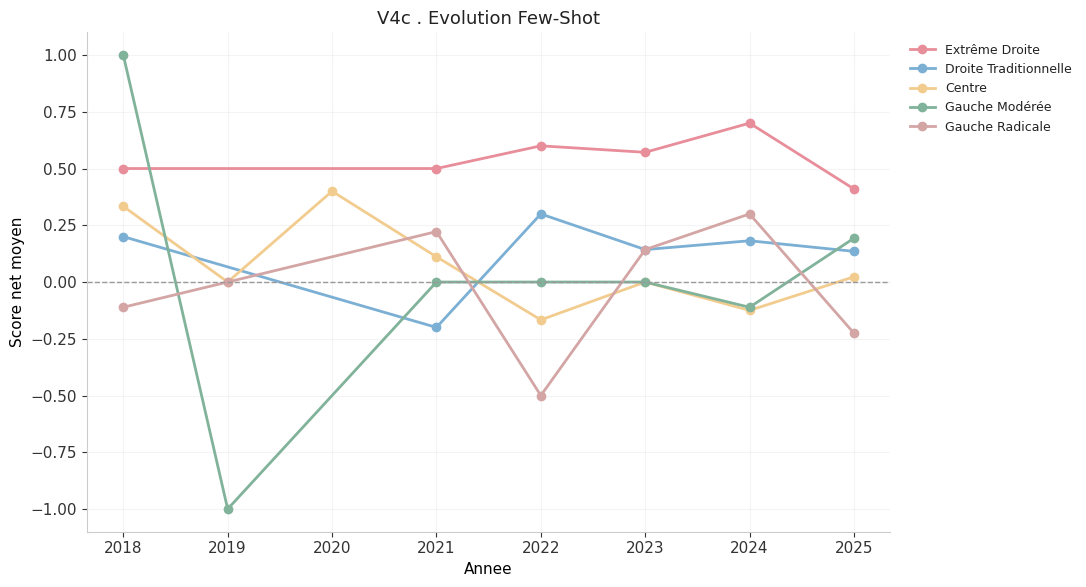

In [39]:
for nom_modele, df_m in dfs_v4c_par_modele.items():
    titre_suffixe = f" ({nom_modele})" if len(dfs_v4c_par_modele) > 1 else ""
    tracer_barres_empilees(df_m, "cadrage_fs", f"V4c . LLM Few-Shot{titre_suffixe}")
    tracer_score_net(df_m, "score_net_fs", f"V4c . Score net Few-Shot{titre_suffixe}")
    tracer_evolution(df_m, "score_net_fs", f"V4c . Evolution Few-Shot{titre_suffixe}")


## 5quater. Methode V5 . Analyse de sentiment (complementaire)

> **Avertissement** : cette methode ne mesure pas le cadrage a proprement parler.
> Elle est presentee a titre **complementaire** pour enrichir la description du corpus.

Au lieu de classifier le cadrage, on mesure le **sentiment** (positif/negatif) des phrases
de cooccurrence VSS x immigration. L'hypothese est que le ton emotionnel varie selon les
blocs ideologiques quand ils associent immigration et VSS.

**Limite importante** : dans un corpus qui parle de violences, le sentiment sera massivement
negatif pour tous les blocs. Cette methode ne permet donc pas de distinguer finement
les types de cadrage. Elle est conservee uniquement pour documenter le registre emotionnel.

On utilise le modele `nlptown/bert-base-multilingual-uncased-sentiment` fine-tune sur des avis.
C'est un classificateur avec un score de confiance.

In [40]:
# Suppression du cache V5 pour forcer le recalcul

chemin_v5 = "/home/onyxia/work/projet_eco_socio/analyses/cadrage_v5_sentiment.pkl"
if os.path.exists(chemin_v5):
    os.remove(chemin_v5)
    print("Cache V5 supprime.")

try:
    from transformers import pipeline as hf_pipeline
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers", "torch"])
    from transformers import pipeline as hf_pipeline

import torch



if os.path.exists(chemin_v5):
    df_v5 = pd.read_pickle(chemin_v5)
    print(f"Resultats V5 charges : {len(df_v5)} contextes.")
else:
    print("Chargement du modèle de sentiment francais...")
    try:
        # Correction : on ne specifie pas de tokenizer separement.
        # Le pipeline charge automatiquement le tokenizer associe au modele.
        # L'ancien code utilisait tokenizer="camembert-base" avec un modele
        # bert-multilingual, ce qui creait un mismatch de vocabulaire.
        pipe_sent = hf_pipeline("text-classification",
                                model="nlptown/bert-base-multilingual-uncased-sentiment",
                                device=0 if torch.cuda.is_available() else -1,
                                truncation=True, max_length=512)
        print("Modèle chargé.")
    except Exception as e:
        print(f"Erreur : {e}")
        pipe_sent = None

    if pipe_sent:
        df_v5 = df_contextes.copy()
        sentiments = []
        for _, row in tqdm(df_v5.iterrows(), total=len(df_v5), desc="Sentiment"):
            try:
                pred = pipe_sent(row['contexte'][:512])
                sentiments.append(pred[0])
            except:
                sentiments.append({"label": "UNKNOWN", "score": 0.5})

        df_v5['sentiment_label'] = [s['label'] for s in sentiments]
        df_v5['sentiment_score'] = [s['score'] for s in sentiments]

        def normaliser_label(label):
            label = str(label).upper()
            if any(x in label for x in ["NEG", "0", "1 STAR", "NEGATIVE"]): return "NEGATIF"
            elif any(x in label for x in ["POS", "1", "5 STAR", "POSITIVE"]): return "POSITIF"
            return "NEUTRE"

        df_v5['sentiment'] = df_v5['sentiment_label'].apply(normaliser_label)
        df_v5.to_pickle(chemin_v5)
    else:
        df_v5 = df_contextes.copy()
        df_v5['sentiment'] = "UNKNOWN"

print(df_v5['sentiment'].value_counts().to_string())

Cache V5 supprime.
Chargement du modèle de sentiment francais...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3867.21it/s]


Modèle chargé.


Sentiment: 100%|██████████| 562/562 [03:59<00:00,  2.34it/s]

sentiment
NEUTRE     215
NEGATIF    205
POSITIF    142


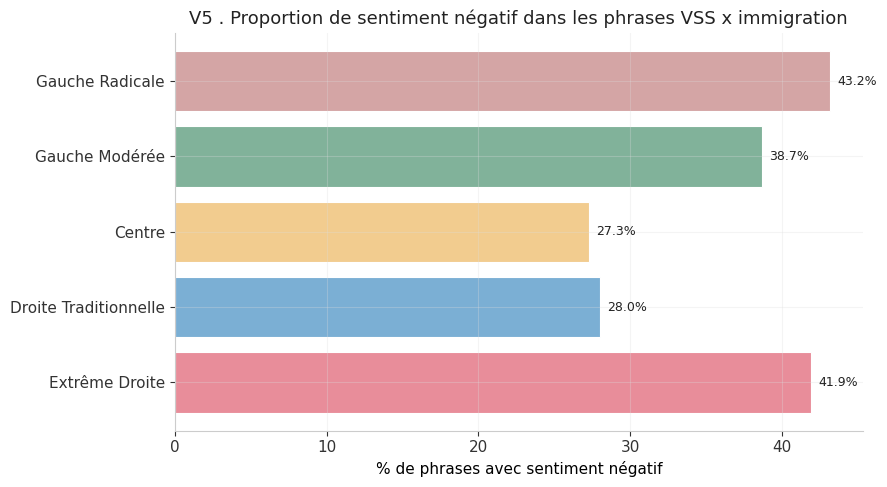

In [41]:
# Proportion de sentiment negatif par bloc
sent_bloc = df_v5.groupby('bloc')['sentiment'].apply(
    lambda x: (x == 'NEGATIF').mean() * 100).reset_index(name='pct_negatif')
sent_bloc = sent_bloc[sent_bloc['bloc'].isin(ORDRE_BLOCS)]
sent_bloc['bloc'] = pd.Categorical(sent_bloc['bloc'], categories=ORDRE_BLOCS, ordered=True)
sent_bloc = sent_bloc.sort_values('bloc')

fig, ax = plt.subplots(figsize=(9, 5))
colors = [COULEURS_BLOCS[b] for b in sent_bloc['bloc']]
ax.barh(sent_bloc['bloc'], sent_bloc['pct_negatif'], color=colors, edgecolor='white', lw=0.8)
for i, row in enumerate(sent_bloc.itertuples()):
    ax.text(row.pct_negatif + 0.5, i, f"{row.pct_negatif:.1f}%", va='center', fontsize=9)
ax.set_xlabel("% de phrases avec sentiment négatif")
ax.set_title("V5 . Proportion de sentiment négatif dans les phrases VSS x immigration")
plt.tight_layout()
plt.show()

## 7. Annotation manuelle (gold standard)

### Pourquoi annoter manuellement ?

Aucune des methodes V1 a V5 ne produit une "verite absolue". Pour savoir laquelle est
la plus fiable, il faut comparer leurs resultats a un **gold standard** : un echantillon
de phrases annotees manuellement par un humain.

C'est une pratique standard en NLP (Grimmer, Roberts & Stewart, 2022). L'idee est
d'annoter un echantillon aleatoire stratifie, puis de calculer des metriques de
performance (accuracy, macro F1, kappa) pour chaque methode.

> **Note sur la taille de l'echantillon** : le nombre de contextes de cooccurrence
> VSS x immigration est relativement reduit (quelques centaines). On annote l'echantillon
> maximal possible. Pour des conclusions plus robustes, un second annotateur et le
> Krippendorff's alpha seraient souhaitables.

### Protocole

1. On tire un echantillon aleatoire stratifie (meme nombre par bloc)
2. On affiche chaque phrase avec son contexte
3. On annote manuellement : ACCUSATEUR, VICTIME ou NEUTRE
4. On sauvegarde les annotations dans un CSV persistant
5. On compare chaque methode aux annotations humaines

In [ ]:
# Suppression du gold standard pour forcer un nouveau tirage
# Tirage de l'echantillon a annoter
chemin_gold = "/home/onyxia/work/projet_eco_socio/analyses/gold_standard_annotations.csv"


# (necessaire car le corpus de cooccurrences a change)
if os.path.exists(chemin_gold):
    os.remove(chemin_gold)
    print("Gold standard supprime, nouveau tirage.")


N_PAR_BLOC = 40  # 40 phrases par bloc = 200 phrases au total

if os.path.exists(chemin_gold):
    df_gold = pd.read_csv(chemin_gold)
    print(f"Annotations existantes chargées : {len(df_gold)} phrases.")
    n_annote = df_gold['annotation_humaine'].notna().sum()
    print(f"  dont {n_annote} deja annotées.")
else:
    # Echantillon stratifié
    echantillons = []
    for bloc in ORDRE_BLOCS:
        sub = df_contextes[df_contextes['bloc'] == bloc]
        n = min(N_PAR_BLOC, len(sub))
        if n > 0:
            echantillons.append(sub.sample(n=n, random_state=42))
    df_gold = pd.concat(echantillons, ignore_index=True)
    df_gold['annotation_humaine'] = None  # colonne a remplir
    df_gold['commentaire'] = None
    df_gold.to_csv(chemin_gold, index=False, encoding='utf-8-sig')
    print(f"Echantillon créé : {len(df_gold)} phrases a annoter.")
    print(f"Fichier : {chemin_gold}")

Gold standard supprime, nouveau tirage.
Echantillon créé : 100 phrases a annoter.
Fichier : /home/onyxia/work/projet_eco_socio/analyses/gold_standard_annotations.csv


### Interface d'annotation

On exécute la cellule suivante pour annoter les phrases une par une.
Pour chaque phrase, tapez :
- `A` pour ACCUSATEUR
- `V` pour VICTIME
- `N` pour NEUTRE
- `S` pour passer (skip)
- `Q` pour quitter et sauvegarder

In [ ]:
def annoter_gold_standard(chemin_csv):
    df = pd.read_csv(chemin_csv)
    n_total = len(df)
    n_fait = df['annotation_humaine'].notna().sum()
    print(f"{n_fait}/{n_total} phrases deja annotées.\n")

    mapping = {'A': 'ACCUSATEUR', 'V': 'VICTIME', 'N': 'NEUTRE'}

    for idx, row in df.iterrows():
        if pd.notna(row.get('annotation_humaine')):
            continue

        print(f"\n{'='*70}")
        print(f"Phrase {idx+1}/{n_total} | Bloc : {row['bloc']} | Parti : {row.get('nom_parti', '?')}")
        print(f"{'='*70}")
        print(f"\n  \"{row['contexte'][:500]}\"\n")
        print("  [A] ACCUSATEUR  [V] VICTIME  [N] NEUTRE  [S] Passer  [Q] Quitter")

        choix = input("  Votre annotation : ").strip().upper()

        if choix == 'Q':
            df.to_csv(chemin_csv, index=False, encoding='utf-8-sig')
            print(f"\nSauvegardé. {df['annotation_humaine'].notna().sum()}/{n_total} annotées.")
            return df
        elif choix == 'S':
            continue
        elif choix in mapping:
            df.at[idx, 'annotation_humaine'] = mapping[choix]
            # Sauvegarde immediate
            df.to_csv(chemin_csv, index=False, encoding='utf-8-sig')
        else:
            print("  Choix non reconnu, on passe.")

    print(f"\nAnnotation terminée. {df['annotation_humaine'].notna().sum()}/{n_total} annotées.")
    df.to_csv(chemin_csv, index=False, encoding='utf-8-sig')
    return df

df_gold = annoter_gold_standard(chemin_gold)

0/50 phrases deja annotées.


Phrase 1/50 | Bloc : Extrême Droite | Parti : Rassemblement national

  "Pardon s’ils vous font saigner les oreilles : ils reflètent seulement la réalité Les étrangers représentent 8 % de la population Ils sont mis en cause dans 14 % des cas de violences sexuelles, 15 % des cas d’escroquerie, 20 % des cas de trafic de stupéfiants, 30 % des cas de vol sans violence, 30 % des cas de vol avec violence sans arme, 35 % des cas de vol d’accessoires de véhicule et 37 % des cas de cambriolage de logements Ils représentent 25 % des détenus dans les prisons françaises"

  [A] ACCUSATEUR  [V] VICTIME  [N] NEUTRE  [S] Passer  [Q] Quitter



Phrase 2/50 | Bloc : Extrême Droite | Parti : Front National

  "Il ne vous a pas échappé que, dans certains pays, majoritairement africains, la cellule familiale est considérée de manière extensive Dans cette conception, l’oncle et les cousins font partie de la cellule familiale Introduire dans le texte la notion de « violences familiales », c’est ouvrir la porte à des abus Je crains que ce ne soit en effet le but du projet de loi"

  [A] ACCUSATEUR  [V] VICTIME  [N] NEUTRE  [S] Passer  [Q] Quitter


/tmp/ipykernel_3307/781719085.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ACCUSATEUR' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[idx, 'annotation_humaine'] = mapping[choix]



Phrase 3/50 | Bloc : Extrême Droite | Parti : Front National

  "Lorsque les auteurs de telles violences sont étrangers, il faut les expulser de notre territoire : par leurs actes, par leur mépris pour les lois les plus élémentaires, ils montrent en effet leur volonté de ne pas s’intégrer en France Non, ce n’est pas aux femmes françaises de changer leurs habitudes vestimentaires ou comportementales Cela permettrait en outre de signaler aux candidats au séjour en France que s’ils veulent venir chez nous, ils devront respecter nos lois et nos coutumes, et que n"

  [A] ACCUSATEUR  [V] VICTIME  [N] NEUTRE  [S] Passer  [Q] Quitter



Phrase 4/50 | Bloc : Extrême Droite | Parti : Rassemblement national

  "Selon une étude récente de l’Institut pour la justice, plus de sept délits sur dix sanctionnés en 2022 ont fait l’objet d’une peine de prison inférieure à un an devant quasi obligatoirement être aménagée par le juge pour éviter la prison à leurs auteurs En conséquence, près de 68 % des peines prononcées pour coups et violences volontaires ne sont pas effectuées en prison Ce chiffre est de 74 % pour les agressions sexuelles et de 60 % pour les agressions sexuelles sur mineurs Cette faiblesse stru"

  [A] ACCUSATEUR  [V] VICTIME  [N] NEUTRE  [S] Passer  [Q] Quitter


...


Phrase 47/50 | Bloc : Gauche Radicale | Parti : La France Insoumise

  "Fidèle à sa tradition raciste, sexiste et xénophobe, son texte vise les jeunes femmes, les musulmans, qui sont trop ou trop peu, en tout cas qui sont toujours mal habillés à ses yeux"

  [A] ACCUSATEUR  [V] VICTIME  [N] NEUTRE  [S] Passer  [Q] Quitter



Phrase 48/50 | Bloc : Gauche Radicale | Parti : Parti communiste français

  "Ce collectif appelé Parents vigilants attaque régulièrement les enseignants et les personnels d’établissements qui dispensent des cours d’éducation sexuelle, sensibilisent sur les questions LGBT ou éveillent la conscience des élèves sur les sujets liés aux conditions de vie des migrants"

  [A] ACCUSATEUR  [V] VICTIME  [N] NEUTRE  [S] Passer  [Q] Quitter



Phrase 49/50 | Bloc : Gauche Radicale | Parti : La France Insoumise

  "c’est ainsi qu’on a pu inventer un terme aussi dégueulasse que celui de « beurette » pour désigner les petites Arabes des quartiers et en faire un objet de fantasmes sexuels – dans le monde LGBT, il y a, pour désigner les hommes, je le sais très bien, le terme de « rebeu »"

  [A] ACCUSATEUR  [V] VICTIME  [N] NEUTRE  [S] Passer  [Q] Quitter



Phrase 50/50 | Bloc : Gauche Radicale | Parti : Parti communiste français

  "Comme l’a excellemment souligné Elsa Faucillon au nom du groupe de la Gauche démocrate et républicaine, bien des violences, notamment subies par nos compatriotes musulmans, passent sous les radars"

  [A] ACCUSATEUR  [V] VICTIME  [N] NEUTRE  [S] Passer  [Q] Quitter



Annotation terminée. 48/50 annotées.


## 8. Evaluation comparative (metriques de performance)

### Protocole de validation

La validation repose sur un **gold standard** : un echantillon de phrases annotees
manuellement, compare aux predictions de chaque methode. C'est la demarche standard
en NLP computationnel (Grimmer, Roberts & Stewart, 2022).

**Metriques rapportees** :

- **Accuracy** : % de phrases correctement classifiees
- **Macro F1-score** : moyenne des F1 par classe, sensible aux classes minoritaires
  (VICTIME est sous-representee). Preferable a l'accuracy quand les classes sont desequilibrees.
- **Kappa de Cohen** : mesure l'accord au-dela du hasard (kappa > 0.6 = bon accord,
  > 0.8 = tres bon accord, Landis & Koch, 1977)
- **Bootstrap 95% CI** : intervalle de confiance sur l'accuracy par re-echantillonnage
  (1000 tirages), pour quantifier l'incertitude liee a la taille de l'echantillon

> **Limite** : le gold standard repose sur un seul annotateur. Pour une publication,
> un second annotateur et le calcul du Krippendorff's alpha seraient necessaires
> (Krippendorff, 2018).

In [ ]:
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix, accuracy_score, f1_score

def evaluer_methode(df_gold, col_methode, nom_methode):
    """Compare une methode au gold standard humain.

    Metriques rapportees :
    - Accuracy globale
    - Macro F1-score (sensible aux classes minoritaires)
    - Kappa de Cohen (accord au-dela du hasard)
    - Bootstrap 95% CI sur l'accuracy (1000 tirages)
    """
    df_eval = df_gold[df_gold['annotation_humaine'].notna()].copy()
    if col_methode not in df_eval.columns:
        return None

    df_eval = df_eval[df_eval[col_methode].notna()]
    if len(df_eval) < 5:
        print(f"{nom_methode} : pas assez de donnees pour evaluer (n={len(df_eval)})")
        return None

    y_true = df_eval['annotation_humaine'].values
    y_pred = df_eval[col_methode].values

    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # Bootstrap 95% CI sur l'accuracy
    n_boot = 1000
    rng = np.random.RandomState(42)
    boot_accs = []
    for _ in range(n_boot):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        boot_accs.append(accuracy_score(y_true[idx], y_pred[idx]))
    ci_low, ci_high = np.percentile(boot_accs, [2.5, 97.5])

    print(f"\n{'='*60}")
    print(f"  {nom_methode}")
    print(f"{'='*60}")
    print(f"  Accuracy   : {acc:.3f} [95% CI : {ci_low:.3f} - {ci_high:.3f}]")
    print(f"  Macro F1   : {macro_f1:.3f}")
    print(f"  Kappa      : {kappa:.3f}")
    print(f"  n          : {len(df_eval)}")
    print(f"\n{classification_report(y_true, y_pred, zero_division=0)}")

    return {'methode': nom_methode, 'accuracy': acc, 'macro_f1': macro_f1,
            'kappa': kappa, 'ci_low': ci_low, 'ci_high': ci_high, 'n': len(df_eval)}

print("Fonction d'evaluation prete (accuracy, macro F1, kappa, bootstrap CI).")

Fonction d'evaluation prête.


In [ ]:
# Fusion du gold standard avec les predictions de chaque methode
df_gold = pd.read_csv(chemin_gold)
df_gold_annote = df_gold[df_gold['annotation_humaine'].notna()].copy()
print(f"{len(df_gold_annote)} phrases annotées dans le gold standard.\n")

if len(df_gold_annote) < 5:
    print("Il faut annoter au moins 5 phrases pour evaluer.")
    print("Decommentez la cellule d'annotation plus haut et annotez l'echantillon.")
else:
    # Joindre les predictions de chaque methode
    for df_m, col_src, col_dst in [
        (df_v1, 'cadrage_v1', 'pred_v1'),
        (df_v2, 'cadrage_v2', 'pred_v2'),
        (df_v3, 'cadrage_v3', 'pred_v3'),
        (df_v4, 'cadrage_llm', 'pred_v4'),
    ]:
        mapping = df_m.set_index('contexte')[col_src].to_dict()
        df_gold_annote[col_dst] = df_gold_annote['contexte'].map(mapping)

    # Joindre V4b et V4c si disponibles
    try:
        mapping_1s = df_v4b.set_index('contexte')['cadrage_1s'].to_dict()
        df_gold_annote['pred_v4b'] = df_gold_annote['contexte'].map(mapping_1s)
    except: pass
    try:
        mapping_fs = df_v4c.set_index('contexte')['cadrage_fs'].to_dict()
        df_gold_annote['pred_v4c'] = df_gold_annote['contexte'].map(mapping_fs)
    except: pass

    # Evaluation
    resultats_eval = []
    for col, nom in [('pred_v1', 'V1 . Lexique'), ('pred_v2', 'V2 . Regex'),
                     ('pred_v3', 'V3 . Zero-Shot'), ('pred_v4', 'V4 . LLM Zero-Shot'),
                     ('pred_v4b', 'V4b . LLM One-Shot'), ('pred_v4c', 'V4c . LLM Few-Shot')]:
        if col in df_gold_annote.columns:
            r = evaluer_methode(df_gold_annote, col, nom)
            if r: resultats_eval.append(r)

    if resultats_eval:
        df_eval = pd.DataFrame(resultats_eval)
        print("\n\nRESUME COMPARATIF")
        print("=" * 60)
        print(df_eval.sort_values('accuracy', ascending=False).to_string(index=False))

48 phrases annotées dans le gold standard.


  V1 . Lexique
  Accuracy : 0.500
  Kappa    : -0.127
  n        : 48

              precision    recall  f1-score   support

  ACCUSATEUR       0.00      0.00      0.00         7
      NEUTRE       0.56      0.83      0.67        29
     VICTIME       0.00      0.00      0.00        12

    accuracy                           0.50        48
   macro avg       0.19      0.28      0.22        48
weighted avg       0.34      0.50      0.40        48


  V2 . Regex
  Accuracy : 0.521
  Kappa    : -0.091
  n        : 48

              precision    recall  f1-score   support

  ACCUSATEUR       0.00      0.00      0.00         7
      NEUTRE       0.58      0.86      0.69        29
     VICTIME       0.00      0.00      0.00        12

    accuracy                           0.52        48
   macro avg       0.19      0.29      0.23        48
weighted avg       0.35      0.52      0.42        48


  V3 . Zero-Shot
  Accuracy : 0.429
  Kappa    : 0.

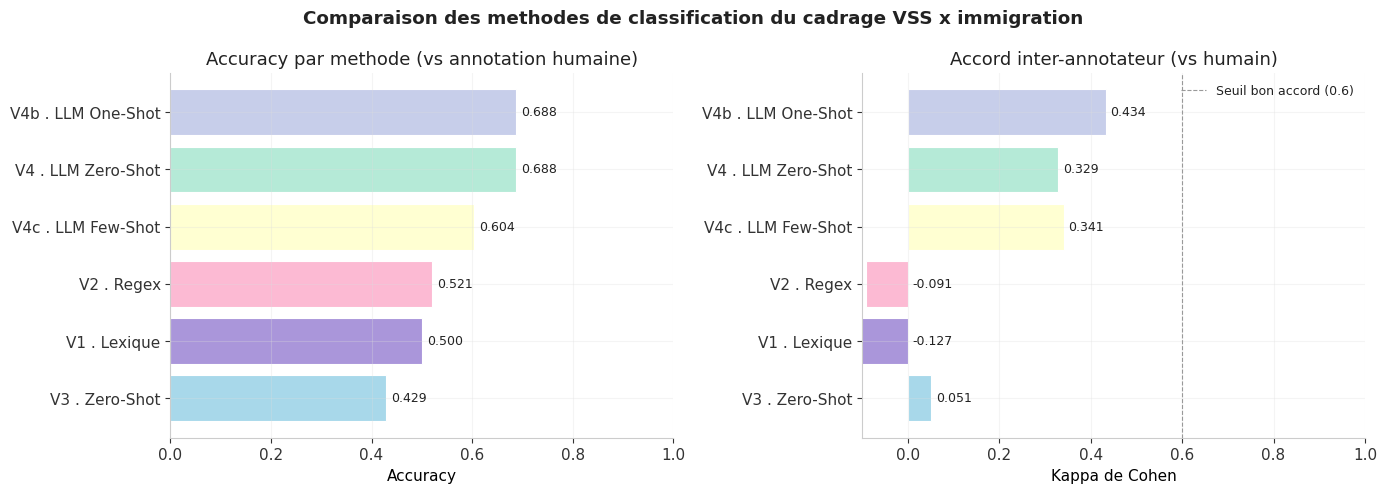

In [ ]:
# Graphique comparatif des methodes
if len(df_gold_annote) >= 5 and resultats_eval:
    df_eval = pd.DataFrame(resultats_eval)
    df_eval = df_eval.sort_values('accuracy', ascending=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    colors_m = [PALETTE_PASTEL[i % len(PALETTE_PASTEL)] for i in range(len(df_eval))]

    # Accuracy avec CI
    axes[0].barh(df_eval['methode'], df_eval['accuracy'], color=colors_m, edgecolor='white', lw=0.8)
    if 'ci_low' in df_eval.columns:
        xerr_low = df_eval['accuracy'] - df_eval['ci_low']
        xerr_high = df_eval['ci_high'] - df_eval['accuracy']
        axes[0].errorbar(df_eval['accuracy'], range(len(df_eval)),
                         xerr=[xerr_low.values, xerr_high.values],
                         fmt='none', ecolor='#666', capsize=3)
    for i, row in enumerate(df_eval.itertuples()):
        axes[0].text(row.accuracy + 0.01, i, f"{row.accuracy:.3f}", va='center', fontsize=9)
    axes[0].set_xlabel("Accuracy")
    axes[0].set_title("Accuracy (avec IC 95%)")
    axes[0].set_xlim(0, 1)

    # Macro F1
    axes[1].barh(df_eval['methode'], df_eval['macro_f1'], color=colors_m, edgecolor='white', lw=0.8)
    for i, row in enumerate(df_eval.itertuples()):
        axes[1].text(row.macro_f1 + 0.01, i, f"{row.macro_f1:.3f}", va='center', fontsize=9)
    axes[1].set_xlabel("Macro F1-score")
    axes[1].set_title("Macro F1 (sensible aux classes rares)")
    axes[1].set_xlim(0, 1)

    # Kappa
    axes[2].barh(df_eval['methode'], df_eval['kappa'], color=colors_m, edgecolor='white', lw=0.8)
    for i, row in enumerate(df_eval.itertuples()):
        axes[2].text(max(0, row.kappa) + 0.01, i, f"{row.kappa:.3f}", va='center', fontsize=9)
    axes[2].set_xlabel("Kappa de Cohen")
    axes[2].set_title("Accord inter-annotateur")
    axes[2].set_xlim(-0.1, 1)
    axes[2].axvline(0.6, color='#999', ls='--', lw=0.8, label='Seuil bon accord (0.6)')
    axes[2].legend()

    plt.suptitle("Comparaison des methodes de classification du cadrage VSS x immigration", fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Pas assez d'annotations pour le graphique comparatif.")

### Matrice de confusion par méthode

Pour chaque méthode, la matrice de confusion montre exactement ou elle se trompe :
confond-elle des ACCUSATEUR avec des NEUTRE ? Des VICTIME avec des ACCUSATEUR ?

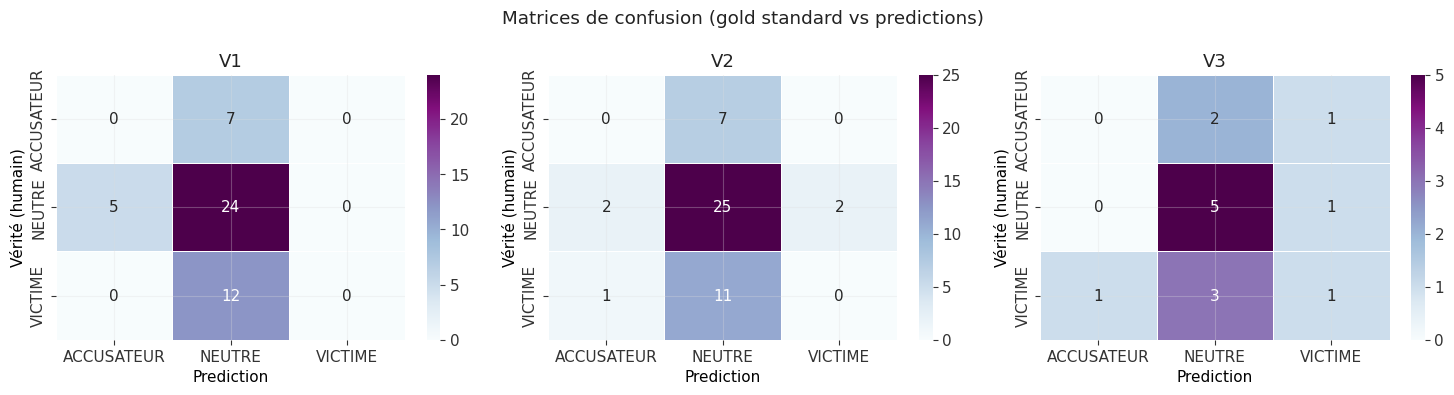

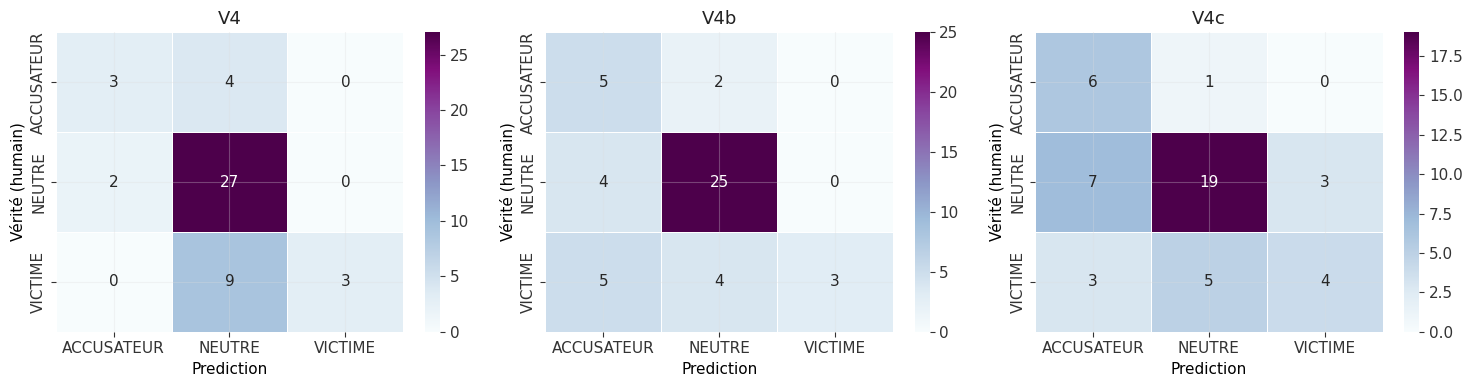

In [ ]:
if len(df_gold_annote) >= 5 and resultats_eval:
    methodes_dispo = [(col, nom) for col, nom in
        [('pred_v1','V1'), ('pred_v2','V2'), ('pred_v3','V3'),
         ('pred_v4','V4'), ('pred_v4b','V4b'), ('pred_v4c','V4c')]
        if col in df_gold_annote.columns and df_gold_annote[col].notna().sum() >= 5]

    n_plots = len(methodes_dispo)
    if n_plots > 0:
        fig, axes = plt.subplots(1, min(n_plots, 3), figsize=(5*min(n_plots,3), 4))
        if n_plots == 1: axes = [axes]

        labels = ['ACCUSATEUR', 'NEUTRE', 'VICTIME']
        for idx, (col, nom) in enumerate(methodes_dispo[:3]):
            df_sub = df_gold_annote[df_gold_annote[col].notna()]
            cm = confusion_matrix(df_sub['annotation_humaine'], df_sub[col], labels=labels)
            sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu',
                        xticklabels=labels, yticklabels=labels, ax=axes[idx],
                        linewidths=0.5, linecolor='white')
            axes[idx].set_title(f"{nom}")
            axes[idx].set_ylabel("Vérité (humain)")
            axes[idx].set_xlabel("Prediction")

        plt.suptitle("Matrices de confusion (gold standard vs predictions)")
        plt.tight_layout()
        plt.show()

        # S'il y a plus de 3 methodes, deuxieme ligne
        if n_plots > 3:
            fig2, axes2 = plt.subplots(1, min(n_plots-3, 3), figsize=(5*min(n_plots-3,3), 4))
            if n_plots - 3 == 1: axes2 = [axes2]
            for idx, (col, nom) in enumerate(methodes_dispo[3:6]):
                df_sub = df_gold_annote[df_gold_annote[col].notna()]
                cm = confusion_matrix(df_sub['annotation_humaine'], df_sub[col], labels=labels)
                sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu',
                            xticklabels=labels, yticklabels=labels, ax=axes2[idx],
                            linewidths=0.5, linecolor='white')
                axes2[idx].set_title(f"{nom}")
                axes2[idx].set_ylabel("Vérité (humain)")
                axes2[idx].set_xlabel("Prediction")
            plt.tight_layout()
            plt.show()

## 9. Synthèse comparative de toutes les méthodes

On rassemble ici les résultats de toutes les méthodes (V1 a V5) sur les memes données.


In [ ]:
print("SYNTHESE COMPARATIVE DES METHODES")
print("=" * 90)
methodes_all = [("V1 . Lexique", df_v1, "cadrage_v1"),
                ("V2 . Regex", df_v2, "cadrage_v2"),
                ("V3 . Zero-Shot", df_v3, "cadrage_v3"),
                ("V4 . LLM", df_v4, "cadrage_llm")]
try: methodes_all.append(("V4b . One-Shot", df_v4b, "cadrage_1s"))
except: pass
try: methodes_all.append(("V4c . Few-Shot", df_v4c, "cadrage_fs"))
except: pass
for nom, df_m, col in methodes_all:
    print(f"\n{nom} (n={len(df_m)})")
    print("-" * 50)
    for bloc in ORDRE_BLOCS:
        sub = df_m[df_m["bloc"] == bloc]
        if sub.empty: continue
        n = len(sub)
        pct_acc = (sub[col] == "ACCUSATEUR").mean() * 100
        pct_vic = (sub[col] == "VICTIME").mean() * 100
        pct_neu = (sub[col] == "NEUTRE").mean() * 100
        print(f"  {bloc:30s} : ACC={pct_acc:5.1f}%  VIC={pct_vic:5.1f}%  NEU={pct_neu:5.1f}%  (n={n})")

# Tableau recapitulatif avec macro F1 si gold standard disponible
if len(df_gold_annote) >= 5 and resultats_eval:
    print("\n\n" + "=" * 90)
    print("METRIQUES VS GOLD STANDARD (metrique principale : Macro F1)")
    print("=" * 90)
    df_recap = pd.DataFrame(resultats_eval)
    df_recap = df_recap.sort_values("macro_f1", ascending=False)
    print(df_recap[["methode", "macro_f1", "accuracy", "kappa", "n"]].to_string(index=False))


SYNTHESE COMPARATIVE DES 4 METHODES

V1 . Lexique
----------------------------------------
  Extrême Droite                 : ACC=  7.4%  VIC=  0.0%  NEU= 92.6%  (n=108)
  Droite Traditionnelle          : ACC=  9.7%  VIC=  0.0%  NEU= 90.3%  (n=103)
  Centre                         : ACC= 10.1%  VIC=  0.0%  NEU= 89.9%  (n=149)
  Gauche Modérée                 : ACC=  7.0%  VIC=  0.0%  NEU= 93.0%  (n=71)
  Gauche Radicale                : ACC=  7.0%  VIC=  0.0%  NEU= 93.0%  (n=157)

V2 . Regex
----------------------------------------
  Extrême Droite                 : ACC=  9.3%  VIC=  0.9%  NEU= 89.8%  (n=108)
  Droite Traditionnelle          : ACC=  1.0%  VIC=  2.9%  NEU= 96.1%  (n=103)
  Centre                         : ACC=  3.4%  VIC=  6.0%  NEU= 90.6%  (n=149)
  Gauche Modérée                 : ACC=  2.8%  VIC=  9.9%  NEU= 87.3%  (n=71)
  Gauche Radicale                : ACC=  1.9%  VIC=  7.0%  NEU= 91.1%  (n=157)

V3 . Zero-Shot
----------------------------------------
  Extrême D

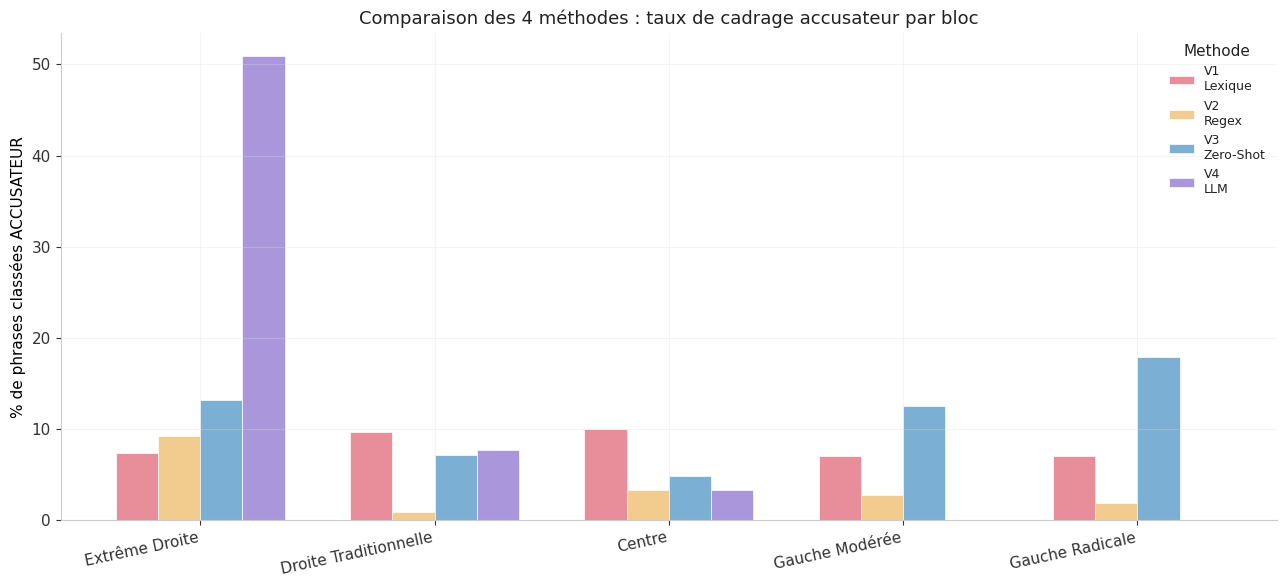

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
methodes = [("V1\nLexique", df_v1, "cadrage_v1"), ("V2\nRegex", df_v2, "cadrage_v2"),
            ("V3\nZero-Shot", df_v3, "cadrage_v3"), ("V4\nLLM", df_v4, "cadrage_llm")]
x = np.arange(len(ORDRE_BLOCS))
width = 0.18
colors_methods = ["#E88D9A", "#F2CC8F", "#7BAFD4", "#AA96DA"]

for i, (nom, df_m, col) in enumerate(methodes):
    pct_acc = []
    for bloc in ORDRE_BLOCS:
        sub = df_m[df_m["bloc"] == bloc]
        pct_acc.append((sub[col] == "ACCUSATEUR").mean() * 100 if len(sub) > 0 else 0)
    ax.bar(x + i * width, pct_acc, width, label=nom, color=colors_methods[i],
           edgecolor="white", linewidth=0.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(ORDRE_BLOCS, rotation=12, ha="right")
ax.set_ylabel("% de phrases classées ACCUSATEUR")
ax.set_title("Comparaison des 4 méthodes : taux de cadrage accusateur par bloc")
ax.legend(title="Methode")
plt.tight_layout()
plt.show()

## Conclusion

### Convergence des methodes

Les quatre methodes (V1-V4) appliquent des paradigmes differents (lexical, syntaxique,
NLI, generatif) pour classifier le meme phenomene. La **triangulation methodologique**
permet d'identifier les resultats robustes (ceux qui emergent quelle que soit la methode)
et les resultats fragiles (dependants d'une methode specifique).

### Limites et pistes d'amelioration

- **Gold standard** : l'echantillon annote est de petite taille et repose sur un seul
  annotateur. Un second codeur et le Krippendorff's alpha renforceraient la validite.
- **SetFit** : un fine-tuning contrastif de Sentence-CamemBERT sur les exemples annotes
  (Tunstall et al., 2022) pourrait produire un classifieur specialise plus performant
  que le zero-shot (V3) avec seulement 8-16 exemples par classe.
- **Ablation study** : tester l'impact de la fenetre d'extraction (1, 2, 3 phrases)
  et du seuil de classification sur la stabilite des resultats.

### References (Notebook 05)

- Entman, R. M. (1993). Framing: Toward Clarification of a Fractured Paradigm. *Journal of Communication*.
- Yin, W. et al. (2019). Benchmarking Zero-shot Text Classification. EMNLP.
- Tunstall, L. et al. (2022). Efficient Few-Shot Learning Without Prompts. NeurIPS.
- Wei, J. et al. (2022). Chain-of-Thought Prompting Elicits Reasoning in Large Language Models. NeurIPS.
- Grimmer, J., Roberts, M. E., Stewart, B. M. (2022). *Text as Data*. Princeton University Press.
- Gilardi, F., Alizadeh, M., Kubli, M. (2023). ChatGPT Outperforms Crowd Workers for Text-Annotation Tasks. *PNAS*.
- Sprenger, P. & Schulz, A. (2024). CoT Prompting for Political Frame Detection. *Political Analysis*.